# Ford GoBike Trip Data: Exploratory Data Analysis and Preprocessing

**Project:** Data Analysis Final Project, Part 2 (Preprocessing and EDA)  
**Team:** *add team member names here*  
**Dataset:** Ford GoBike trips, February 2019 (`fordgobike-tripdataFor201902.csv`)  
**Tools:** Python, pandas, matplotlib, seaborn

This notebook cleans the Ford GoBike trip data, builds new features, and explores who rides, when they ride and where. It ends by exporting a cleaned dataset that feeds the PostgreSQL database and the interactive dashboard.

## Executive Summary

We analyzed 183,412 bike-share trips from February 2019. After cleaning, **182,798 trips (99.7%)** remain. The main findings are:

1. **Riders are mostly members.** Subscribers make 89% of the trips, men make 71%, and the typical rider is 32 years old (half of the riders are between 27 and 39).
2. **Trips are short.** The median trip lasts 8.6 minutes and covers 1.4 km in a straight line. 99% of trips are under one hour.
3. **Customers ride differently from Subscribers.** Their median trip is about 1.6 times longer (about 13 vs 8.2 minutes), and 28% of their trips happen on weekends, compared with 15% for Subscribers.
4. **Commuting drives the system.** A weekday has about twice the trips of a weekend day. Weekday trips peak at 8:00 and 17:00, and 60% of them start in the morning and evening rush windows.
5. **Demand concentrates downtown.** Market St at 10th St is the busiest start station (3,897 trips). The Caltrain station on Townsend St receives 1,308 more trips than it starts, so bikes pile up there and need to be moved.
6. **Age does not explain behavior.** Age has almost no relationship with trip duration (correlation 0.02) or with user type.
7. **Data quality needs attention.** Birth year and gender are missing for 4.5% of trips, and much more often for Customers (16.3%) than for Subscribers (3.1%). We kept these trips and labeled them *Unknown* instead of inventing values.

## Table of Contents

- [Introduction](#introduction)
- [Setup](#setup)
- [Loading and First Look](#loading-and-first-look)
- [Data Cleaning](#data-cleaning)
- [Feature Engineering](#feature-engineering)
- [Univariate Exploration](#univariate-exploration)
- [Outlier Treatment](#outlier-treatment)
- [Additional Features](#additional-features)
- [Bivariate Exploration](#bivariate-exploration)
- [Multivariate Exploration](#multivariate-exploration)
- [Time Analysis](#time-analysis)
- [User Analysis](#user-analysis)
- [Station and Route Analysis](#station-and-route-analysis)
- [Encoding and Scaling](#encoding-and-scaling)
- [Export the Cleaned Dataset](#export-the-cleaned-dataset)
- [Conclusions](#conclusions)

## Introduction

Ford GoBike (now Bay Wheels) is a bike-sharing system in the San Francisco Bay Area. The dataset has one row per trip in February 2019: when and where each trip started and ended, how long it lasted, which bike was used, and a few self-reported details about the rider.

### Objectives

1. Clean the data: fix missing values, handle outliers and standardize categories.
2. Engineer features: duration in minutes, weekend flag, age groups and more.
3. Encode and scale the data for modeling.
4. Answer the 15 investigative questions (univariate, bivariate and multivariate), plus extra questions about time, users and stations.
5. Export a cleaned dataset for the database and the dashboard.

### Investigative questions

**Univariate:** Q1 user type, Q2 Bike Share for All, Q3 ages, Q4 age outliers, Q5 duration in minutes, Q6 gender, Q7 duration in hours.  
**Bivariate:** Q8 average duration by user type, Q9 duration by gender, Q10 duration distribution by user type, Q11 age by user type, Q12 age by gender.  
**Multivariate:** Q13 correlation of all numeric variables, Q14 relationships between the main variables, Q15 focused correlation heatmap, Q16 duration by user type and age group.  
**Extra:** time (T1-T4), users (U1) and stations (S1-S4).

### Data dictionary (raw file)

| Column | Description | Stored as |
| :--- | :--- | :--- |
| `duration_sec` | Trip duration in seconds | integer |
| `start_time`, `end_time` | Date and time the trip started and ended | text (converted below) |
| `start_station_id`, `end_station_id` | Station identifiers | number (missing for 197 trips) |
| `start_station_name`, `end_station_name` | Station names | text (missing for 197 trips) |
| `start_station_latitude`, `start_station_longitude` | Location of the start station | decimal |
| `end_station_latitude`, `end_station_longitude` | Location of the end station | decimal |
| `bike_id` | Identifier of the bike | integer |
| `user_type` | `Subscriber` (member) or `Customer` (casual rider) | text |
| `member_birth_year` | Rider's birth year, self-reported | number (missing for 4.5%) |
| `member_gender` | `Male`, `Female` or `Other`, self-reported | text (missing for 4.5%) |
| `bike_share_for_all_trip` | `Yes` if the trip belongs to the Bike Share for All program | text |

## Setup

We load the libraries, set the analysis rules in one place, and define a few helper functions. Changing a rule (for example the maximum trip duration) only requires editing one line.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, PercentFormatter

%matplotlib inline

In [9]:
# Paths and analysis rules: change them here, not inside the code below
from pathlib import Path

# Find the project's data folder, regardless of where the notebook is run from
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
DATA_DIR = PROJECT_ROOT / 'data'

DATA_PATH = DATA_DIR / 'fordgobike-tripdataFor201902.csv'
CLEAN_PATH = DATA_DIR / 'fordgobike_cleaned.csv'
REFERENCE_YEAR = 2019      # trips are from Feb 2019, so age = 2019 - birth year
MAX_AGE = 100              # ages above this are treated as invalid
MAX_DURATION_MIN = 180     # trips longer than 3 hours are removed

# One plot style for the whole notebook
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11

# Fixed colors and orders so every chart looks consistent
USER_COLORS = {'Subscriber': '#1f77b4', 'Customer': '#ff7f0e'}
USER_ORDER = ['Subscriber', 'Customer']
DAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
GENDER_ORDER = ['Male', 'Female', 'Other', 'Unknown']
AGE_GROUP_ORDER = ['Young', 'Adult', 'Senior', 'Unknown']

# Show 175,000 instead of 175000 on chart axes
thousands = FuncFormatter(lambda x, _: f'{x:,.0f}')

In [10]:
# Helper functions used throughout the notebook
cleaning_log = []


def log_step(step, rows_before, rows_after, reason):
    """Record one cleaning step, so the cleaning log at the end builds itself."""
    first = rows_before is None
    cleaning_log.append({
        'Step': step,
        'Rows before': '-' if first else f'{rows_before:,}',
        'Rows after': f'{rows_after:,}',
        'Rows removed': '-' if first else f'{rows_before - rows_after:,}',
        'Reason': reason,
    })


def count_bar(series, title, xlabel, order=None, figsize=(6, 4)):
    """Bar chart of trips per category, labeled with the count and the percentage."""
    counts = series.value_counts()
    if order:
        counts = counts.reindex(order)
    plt.figure(figsize=figsize)
    ax = sns.barplot(x=counts.index.astype(str), y=counts.values)
    ax.bar_label(ax.containers[0],
                 labels=[f'{v:,}\n({v / counts.sum():.1%})' for v in counts.values],
                 padding=3)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Number of trips')
    ax.set_ylim(0, counts.max() * 1.22)
    ax.yaxis.set_major_formatter(thousands)
    plt.show()


def haversine_km(lat1, lon1, lat2, lon2):
    """Straight-line distance in kilometres between two latitude/longitude points."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * 6371.0088 * np.arcsin(np.sqrt(a))

## Loading and First Look

We start with a high-level look at the raw file: its size, first rows, column types, summary statistics and number of distinct values.

In [11]:
# Load the raw file
df = pd.read_csv(DATA_PATH)
log_step('Raw file loaded', None, len(df), 'Initial dataset')

# 1. Size of the dataset
print('rows, columns:', df.shape)

rows, columns: (183412, 16)


In [12]:
# 2. First rows
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,2019-02-28 18:53:21.7890,2019-03-01 06:42:03.0560,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,2019-02-28 23:54:18.5490,2019-03-01 00:20:44.0740,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


In [13]:
# 3. Column types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 183412 entries, 0 to 183411
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183412 non-null  int64  
 1   start_time               183412 non-null  str    
 2   end_time                 183412 non-null  str    
 3   start_station_id         183215 non-null  float64
 4   start_station_name       183215 non-null  str    
 5   start_station_latitude   183412 non-null  float64
 6   start_station_longitude  183412 non-null  float64
 7   end_station_id           183215 non-null  float64
 8   end_station_name         183215 non-null  str    
 9   end_station_latitude     183412 non-null  float64
 10  end_station_longitude    183412 non-null  float64
 11  bike_id                  183412 non-null  int64  
 12  user_type                183412 non-null  str    
 13  member_birth_year        175147 non-null  float64
 14  member_gender  

In [14]:
# 4. Summary statistics for numeric columns
df.describe().round(2)

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,183412.00,183215.00,183412.00,183412.00,183215.00,183412.00,183412.00,183412.00,175147.00
mean,726.08,138.59,37.77,-122.35,136.25,37.77,-122.35,4472.91,1984.81
std,1794.39,111.78,0.10,0.12,111.52,0.10,0.12,1664.38,10.12
min,61.00,3.00,37.32,-122.45,3.00,37.32,-122.45,11.00,1878.00
25%,325.00,47.00,37.77,-122.41,44.00,37.77,-122.41,3777.00,1980.00
50%,514.00,104.00,37.78,-122.40,100.00,37.78,-122.40,4958.00,1987.00
75%,796.00,239.00,37.80,-122.29,235.00,37.80,-122.29,5502.00,1992.00
max,85444.00,398.00,37.88,-121.87,398.00,37.88,-121.87,6645.00,2001.00


In [15]:
# 5. Number of distinct values in each column
df.nunique()

duration_sec                 4752
start_time                 183401
end_time                   183397
start_station_id              329
start_station_name            329
start_station_latitude        334
start_station_longitude       335
end_station_id                329
end_station_name              329
end_station_latitude          335
end_station_longitude         335
bike_id                      4646
user_type                       2
member_birth_year              75
member_gender                   3
bike_share_for_all_trip         2
dtype: int64

### What is the structure of the dataset?

The raw file has **183,412 rows** (one per trip) and **16 columns**: 9 are stored as numbers and 7 as text. Some numeric-looking columns are really identifiers (`start_station_id`, `end_station_id`, `bike_id`) and should never be averaged. The two time columns are stored as text and must be converted to real datetimes.

### What are the main features of interest?

- **Trip duration** is our main outcome: how long do people ride?
- **User type**, **age** and **gender** describe who rides.
- **Time** and **stations** describe when and where they ride.

### What features support the investigation?

- The time columns tell us when trips happen (hour, weekday, day of the month).
- The station names and coordinates tell us where trips start and end.
- The birth year gives us age.

Two facts shape the whole analysis. First, birth year and gender are missing for 4.5% of trips. Second, duration is strongly right-skewed (raw mean 12.1 minutes vs median 8.6), so we report medians next to means.

## Data Cleaning

We check the data in this order: missing values, duplicates, then text and category standardization. Every step that changes the number of rows is recorded in the cleaning log (see [Outlier Treatment](#outlier-treatment)).

### Missing values

First we find where values are missing, then check whether they are missing at random.

In [16]:
# Which columns contain missing values, and how many?
missing = df.isna().sum()
missing = missing[missing > 0].to_frame('missing values')
missing['share of rows'] = (missing['missing values'] / len(df)).map('{:.2%}'.format)
missing

,missing values,share of rows
start_station_id,197,0.11%
start_station_name,197,0.11%
end_station_id,197,0.11%
end_station_name,197,0.11%
member_birth_year,8265,4.51%
member_gender,8265,4.51%


In [17]:
# Are the missing values random? Compare Customers and Subscribers.
by_type = (df.assign(birth_year_missing=df['member_birth_year'].isna())
             .groupby('user_type')['birth_year_missing']
             .agg(['sum', 'count', 'mean']))
by_type.columns = ['missing birth years', 'trips', 'share missing']
by_type['share missing'] = by_type['share missing'].map('{:.1%}'.format)
display(by_type)

same_rows = (df['member_birth_year'].isna() == df['member_gender'].isna()).all()
print('Birth year and gender are missing on exactly the same rows:', same_rows)

,missing birth years,trips,share missing
user_type,,,
Customer,3237,19868,16.3%
Subscriber,5028,163544,3.1%


Birth year and gender are missing on exactly the same rows: True


In [18]:
# Trips without a station: where are they?
no_station = df[df['start_station_id'].isna()]
print('trips without a start station:', len(no_station))
print('start and end station missing on the same rows:',
      (df['start_station_id'].isna() == df['end_station_id'].isna()).all())
print('latitude range of these trips :', no_station['start_station_latitude'].min().round(2),
      'to', no_station['start_station_latitude'].max().round(2))
print('longitude range of these trips:', no_station['start_station_longitude'].min().round(2),
      'to', no_station['start_station_longitude'].max().round(2))

trips without a start station: 197
start and end station missing on the same rows: True
latitude range of these trips : 37.38 to 37.42
longitude range of these trips: -121.98 to -121.92


**What the checks show**

- Birth year and gender are missing on **exactly the same 8,265 trips (4.5%)**.
- The gaps are **not random**: 16.3% of Customer trips have no birth year, against 3.1% of Subscriber trips. Customers often ride without a full profile.
- **197 trips (0.1%)** have no station information. Start and end are missing together, and all of them are in San Jose (latitude 37.38 to 37.42), outside the docked-station network.

**Decisions**

| Problem | Decision | Reason |
| :--- | :--- | :--- |
| Missing gender | Label it `Unknown` | Keeps the trip. `Unknown` is kept separate from the real value `Other`. |
| Missing birth year | Keep it empty; age group becomes `Unknown` | Filling it with the median would invent ages for 4.5% of trips and hide the difference between Customers and Subscribers. |
| No station | Remove the 197 trips | They cannot be used for station or route analysis, and they are only 0.1% of the data. |

### Duplicate rows

A duplicated trip would inflate every count. We check for fully identical rows, and also for the same bike starting two trips at the same instant, which is impossible. **Result: no duplicates were found.**

In [19]:
# Fully duplicated rows, and duplicates on the natural key (a bike cannot start two trips at the same instant)
n_full = df.duplicated().sum()
n_key = df.duplicated(['start_time', 'bike_id']).sum()
print('fully duplicated rows:', n_full)
print('duplicates on start_time + bike_id:', n_key)

rows_before = len(df)
df = df.drop_duplicates()
log_step('Remove duplicate rows', rows_before, len(df), 'Checked full-row duplicates; none found')

fully duplicated rows: 0
duplicates on start_time + bike_id: 0


### Applying the missing-value decisions

In [20]:
# Missing gender becomes an explicit 'Unknown' label; missing birth year stays empty (NaN)
df['member_gender'] = df['member_gender'].fillna('Unknown')

# Trips without station information cannot be used for station or route analysis
station_cols = ['start_station_id', 'start_station_name', 'end_station_id', 'end_station_name']
rows_before = len(df)
df = df.dropna(subset=station_cols).copy()
log_step('Remove trips without a station', rows_before, len(df), 'Missing essential station data')

# Station IDs are identifiers, so store them as integers (they were floats only because of the missing values)
df[['start_station_id', 'end_station_id']] = df[['start_station_id', 'end_station_id']].astype('int64')
print(df[['start_station_id', 'end_station_id']].dtypes.to_frame('dtype'))

                  dtype
start_station_id  int64
end_station_id    int64


### Standardizing text and categories

One station name has a double space: `San Francisco Caltrain Station 2  (Townsend St at 4th St)`. It appears in 8,401 station fields (3,544 start and 4,857 end) and it is one of the busiest stations. Exact-text matching (filters, lookups, joins with other data) would treat it as a different name from the version with one space. After trimming, all 329 names are still unique, so no stations were merged. The other categorical columns needed no fixing.

In [21]:
# Station names: count names with extra spaces, then trim and collapse them
name_cols = ['start_station_name', 'end_station_name']

for c in name_cols:
    print(c, '- names with extra spaces (before):', df[c].str.contains(r'\s{2,}').sum())

for c in name_cols:
    df[c] = df[c].str.strip().str.replace(r'\s+', ' ', regex=True)

for c in name_cols:
    print(c, '- names with extra spaces (after):', df[c].str.contains(r'\s{2,}').sum())

start_station_name - names with extra spaces (before): 3544
end_station_name - names with extra spaces (before): 4857
start_station_name - names with extra spaces (after): 0
end_station_name - names with extra spaces (after): 0


In [22]:
# Low-cardinality text columns become categories
cat_cols = ['member_gender', 'user_type', 'bike_share_for_all_trip']
df[cat_cols] = df[cat_cols].astype('category')

for c in cat_cols:
    print(df[c].value_counts(dropna=False).to_frame('trips'), '\n')

                trips
member_gender        
Male           130500
Female          40805
Unknown          8263
Other            3647 

             trips
user_type         
Subscriber  163414
Customer     19801 

                          trips
bike_share_for_all_trip        
No                       165869
Yes                       17346 



In [23]:
# Validate the station table: every ID must map to exactly one name and one location
stations = pd.concat([
    df[['start_station_id', 'start_station_name', 'start_station_latitude', 'start_station_longitude']]
      .set_axis(['id', 'name', 'lat', 'lon'], axis=1),
    df[['end_station_id', 'end_station_name', 'end_station_latitude', 'end_station_longitude']]
      .set_axis(['id', 'name', 'lat', 'lon'], axis=1),
]).drop_duplicates().reset_index(drop=True)

print('unique station IDs:', stations['id'].nunique())
print('IDs with more than one name:', (stations.groupby('id')['name'].nunique() > 1).sum())
print('rows in the station table:', len(stations))

unique station IDs: 329
IDs with more than one name: 0
rows in the station table: 329


**Checkpoint:** 183,215 trips remain. Station IDs are integers, each of the 329 IDs maps to exactly one name and one location, and the categories are consistent. The `stations` table above is reused for the station analysis and can become `dim_station` in the database.

## Feature Engineering

We build the columns needed for the analysis: age, duration in minutes and hours, and a set of time features.

### Age

Age is the trip year (2019) minus the birth year. We store it as a nullable integer, so unknown ages stay empty. We create it before checking for outliers, because Q3 and Q4 investigate the raw ages.

In [24]:
# Age at the time of the trip (all trips are from 2019)
df['age'] = REFERENCE_YEAR - df['member_birth_year']
df['age'] = df['age'].astype('Int64')   # nullable integer: unknown ages stay empty

print('age column type:', df['age'].dtype)
df[['member_birth_year', 'age']].head()

age column type: Int64


,member_birth_year,age
0,1984.0,35
1,NaN,<NA>
2,1972.0,47
3,1989.0,30
4,1974.0,45


### Trip duration in minutes and hours

Seconds are hard to read, so we add minutes (used in most charts) and hours (needed for Q7).

In [25]:
# Trip duration in minutes and hours (easier to read than seconds)
df['duration_min'] = df['duration_sec'] / 60
df['duration_hour'] = df['duration_sec'] / 3600
df[['duration_sec', 'duration_min', 'duration_hour']].head()

,duration_sec,duration_min,duration_hour
0,52185,869.750000,14.495833
1,42521,708.683333,11.811389
2,61854,1030.900000,17.181667
3,36490,608.166667,10.136111
4,1585,26.416667,0.440278


### Time features

The time columns are converted from text to datetimes, and then split into parts:

| Column | Meaning | Example (first trip) |
| :--- | :--- | :--- |
| `start_date` | Calendar date | 2019-02-28 |
| `start_hour` | Hour of the day, 0-23 | 17 |
| `start_day` | Day of the month | 28 |
| `day_of_week` | Weekday name, ordered Monday to Sunday | Thursday |
| `day_of_week_num` | Weekday number, 0 = Monday ... 6 = Sunday | 3 |
| `start_month`, `start_year` | Month and year | 2, 2019 |
| `is_weekend` | `True` for Saturday and Sunday | False |

In [26]:
# Convert the time columns from text to real datetimes
df['start_time'] = pd.to_datetime(df['start_time'])
df['end_time'] = pd.to_datetime(df['end_time'])

print(df[['start_time', 'end_time']].dtypes.to_frame('dtype'))
print('start_time range:', df['start_time'].min(), '->', df['start_time'].max())

                     dtype
start_time  datetime64[us]
end_time    datetime64[us]
start_time range: 2019-02-01 00:00:20.636000 -> 2019-02-28 23:59:18.548000


In [27]:
# Time features used for the weekday, hour and calendar analysis
df['start_date'] = df['start_time'].dt.normalize()
df['start_year'] = df['start_time'].dt.year
df['start_month'] = df['start_time'].dt.month
df['start_day'] = df['start_time'].dt.day                 # day of the month (1-28)
df['start_hour'] = df['start_time'].dt.hour               # hour of the day (0-23)
df['day_of_week_num'] = df['start_time'].dt.dayofweek     # 0 = Monday ... 6 = Sunday
df['day_of_week'] = pd.Categorical(df['start_time'].dt.day_name(), categories=DAY_ORDER, ordered=True)
df['is_weekend'] = df['day_of_week_num'] >= 5             # Saturday and Sunday

df[['start_time', 'start_date', 'start_hour', 'start_day', 'day_of_week', 'is_weekend']].head()

,start_time,start_date,start_hour,start_day,day_of_week,is_weekend
0,2019-02-28 17:32:10.145,2019-02-28,17,28,Thursday,False
1,2019-02-28 18:53:21.789,2019-02-28,18,28,Thursday,False
2,2019-02-28 12:13:13.218,2019-02-28,12,28,Thursday,False
3,2019-02-28 17:54:26.010,2019-02-28,17,28,Thursday,False
4,2019-02-28 23:54:18.549,2019-02-28,23,28,Thursday,False


In [28]:
# Validate the time columns
print('end before start:', (df['end_time'] < df['start_time']).sum())
print('starts outside February:', (df['start_time'].dt.month != 2).sum())
gap = ((df['end_time'] - df['start_time']).dt.total_seconds() - df['duration_sec']).abs().max()
print('largest gap between (end - start) and duration_sec, in seconds:', round(gap, 3))
print('weekend share of trips:', round(df['is_weekend'].mean(), 3))

end before start: 0
starts outside February: 0
largest gap between (end - start) and duration_sec, in seconds: 0.999
weekend share of trips: 0.169


**Validation result:** every trip ends after it starts, every trip starts in February 2019, and the duration matches the difference between end and start within one second. Weekends account for about 17% of trips.

## Univariate Exploration

Here we look at one variable at a time. This section uses the data **before outlier removal (183,215 trips)**, because Q3 to Q5 are about finding outliers.

### Q1. What is the distribution of user type?

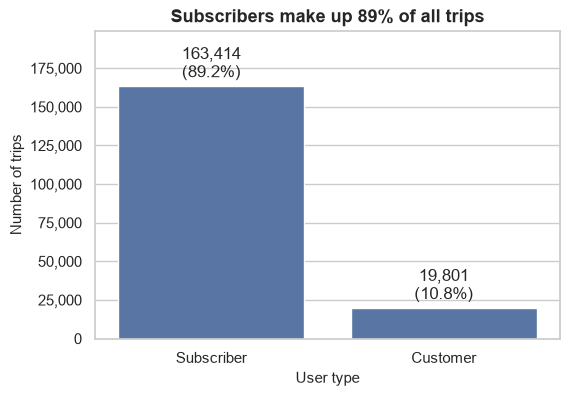

In [29]:
share = (df['user_type'] == 'Subscriber').mean()
count_bar(df['user_type'], f'Subscribers make up {share:.0%} of all trips',
          'User type', order=USER_ORDER)

**What we see:** 163,414 trips (89.2%) were made by Subscribers and 19,801 (10.8%) by Customers.

**Why it matters:** The system is used mainly by regular members, so any statement about a "typical trip" mostly describes Subscribers. Customers are a small but distinct group, and we compare them with Subscribers in the bivariate section.

### Q2. What is the distribution of Bike Share for All trips?

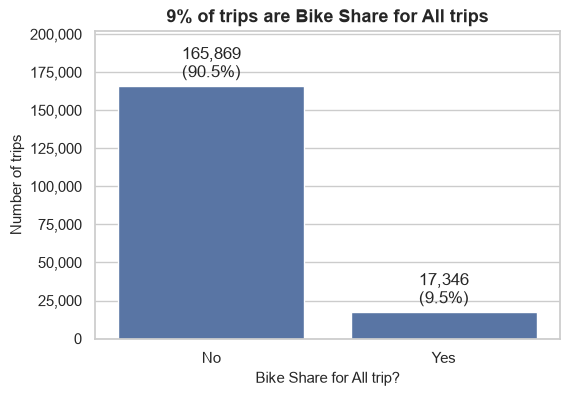

In [30]:
share = (df['bike_share_for_all_trip'] == 'Yes').mean()
count_bar(df['bike_share_for_all_trip'], f'{share:.0%} of trips are Bike Share for All trips',
          'Bike Share for All trip?', order=['No', 'Yes'])

**What we see:** 17,346 trips (9.5%) belong to the Bike Share for All program and 165,869 (90.5%) do not.

**Why it matters:** After cleaning, every Bike Share for All trip is made by a Subscriber (17,317 trips, 10.6% of Subscriber trips), and no Customer trip is part of the program. This is consistent with a program that is a membership option.

### Q3. What is the distribution of users' ages?

In [31]:
age_known = df['age'].dropna().astype(int)
print(f'min age: {age_known.min()}   max age: {age_known.max()}')
print(f'mean age: {age_known.mean():.1f}   median age: {age_known.median():.0f}')
print(f'trips with a known age: {len(age_known):,} of {len(df):,}')

min age: 18   max age: 141
mean age: 34.2   median age: 32
trips with a known age: 174,952 of 183,215


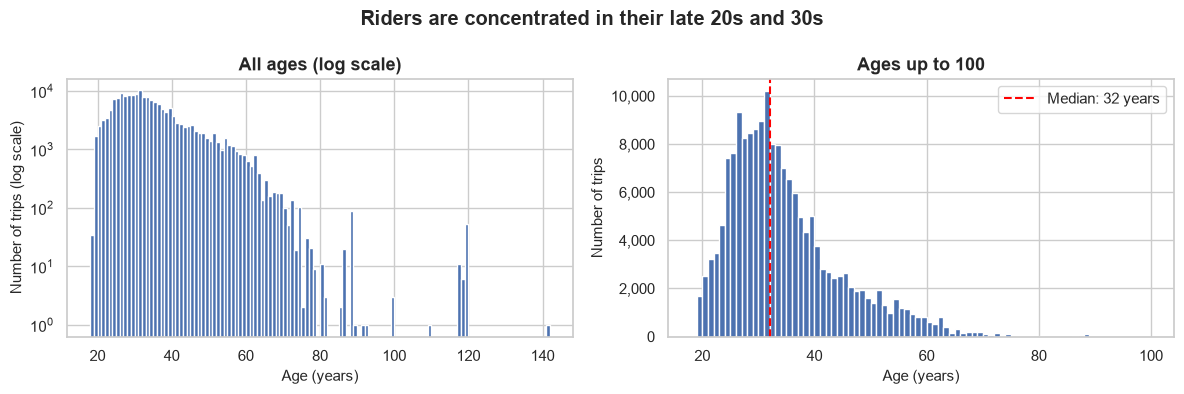

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: every age, log scale, so the rare extreme values are visible
axes[0].hist(age_known, bins=range(age_known.min(), age_known.max() + 2), edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_title('All ages (log scale)')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Number of trips (log scale)')

# Right: realistic ages only, with the median marked
realistic = age_known[age_known <= MAX_AGE]
axes[1].hist(realistic, bins=range(realistic.min(), realistic.max() + 2), edgecolor='white')
axes[1].axvline(realistic.median(), color='red', linestyle='--', label=f'Median: {realistic.median():.0f} years')
axes[1].set_title(f'Ages up to {MAX_AGE}')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Number of trips')
axes[1].yaxis.set_major_formatter(thousands)
axes[1].legend()

fig.suptitle('Riders are concentrated in their late 20s and 30s', fontweight='bold')
plt.tight_layout()
plt.show()

**What we see:** Ages run from 18 to 141, with a median of 32 and a mean of 34.2. Half of the riders with a known age are between 27 and 39, and 63.7% are between 25 and 39. The distribution is right-skewed: only 2.0% of riders are older than 60. The log-scale chart on the left also shows a few impossible ages above 100.

**Why it matters:** The user base is mainly young adults. 8,263 trips (4.5%) have no age and are left out of the age charts.

### Q4. Do users' ages have outlier values?

trips with an age above 100: 72

birth years of these riders:


,trips
member_birth_year,
1878,1
1900,53
1901,6
1902,11
1910,1


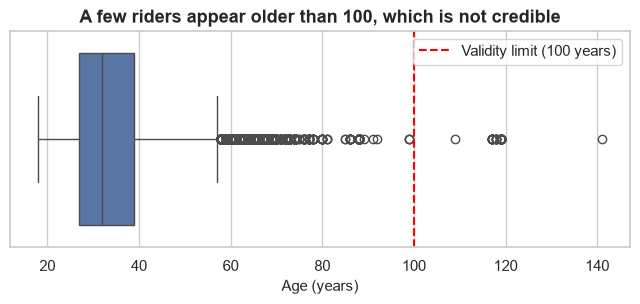

In [33]:
implausible = df[df['age'] > MAX_AGE]
print(f'trips with an age above {MAX_AGE}: {len(implausible)}')
print('\nbirth years of these riders:')
display(implausible['member_birth_year'].astype(int).value_counts().sort_index().to_frame('trips'))

plt.figure(figsize=(8, 2.8))
sns.boxplot(x=age_known, orient='h', color='#4c72b0')
plt.axvline(MAX_AGE, color='red', linestyle='--', label=f'Validity limit ({MAX_AGE} years)')
plt.title('A few riders appear older than 100, which is not credible')
plt.xlabel('Age (years)')
plt.legend(loc='upper right')
plt.show()

**What we see:** Yes. 72 trips report birth years 1878 (1 trip), 1900 (53), 1901 (6), 1902 (11) and 1910 (1), which imply ages between 109 and 141. These look like data-entry errors or placeholder values.

**Why it matters:** The boxplot also flags many riders above about 57 as statistical outliers, but riders in their 60s, 70s and 80s are plausible. A rule based on the interquartile range would remove valid riders, so we use a domain rule instead: **an age above 100 is invalid**. We treat it in the [Outlier Treatment](#outlier-treatment) section.

### Q5. What is the distribution of trip duration in minutes?

In [34]:
p99 = df['duration_min'].quantile(0.99)
display(df['duration_min'].describe(percentiles=[.5, .9, .95, .99]).round(2).to_frame('minutes'))

for limit in [30, 60, MAX_DURATION_MIN, 300]:
    n = (df['duration_min'] > limit).sum()
    print(f"trips longer than {limit} min: {n:,} ({n / len(df):.2%})")

,minutes
count,183215.00
mean,12.10
std,29.92
min,1.02
50%,8.57
90%,19.63
95%,26.17
99%,57.61
max,1424.07


trips longer than 30 min: 6,750 (3.68%)
trips longer than 60 min: 1,706 (0.93%)
trips longer than 180 min: 417 (0.23%)
trips longer than 300 min: 237 (0.13%)


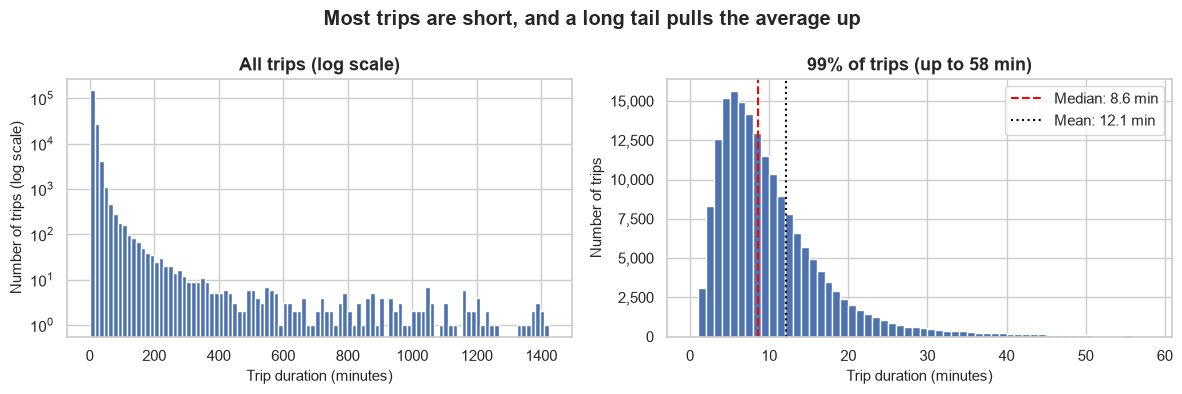

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: the full range on a log scale
axes[0].hist(df['duration_min'], bins=100, edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_title('All trips (log scale)')
axes[0].set_xlabel('Trip duration (minutes)')
axes[0].set_ylabel('Number of trips (log scale)')

# Right: zoom to 99% of the trips, with the median and mean marked
zoom = df[df['duration_min'] <= p99]
axes[1].hist(zoom['duration_min'], bins=np.arange(0, p99 + 1, 1), edgecolor='white')
axes[1].axvline(df['duration_min'].median(), color='red', linestyle='--',
                label=f"Median: {df['duration_min'].median():.1f} min")
axes[1].axvline(df['duration_min'].mean(), color='black', linestyle=':',
                label=f"Mean: {df['duration_min'].mean():.1f} min")
axes[1].set_title(f'99% of trips (up to {p99:.0f} min)')
axes[1].set_xlabel('Trip duration (minutes)')
axes[1].set_ylabel('Number of trips')
axes[1].yaxis.set_major_formatter(thousands)
axes[1].legend()

fig.suptitle('Most trips are short, and a long tail pulls the average up', fontweight='bold')
plt.tight_layout()
plt.show()

**What we see:** The median trip lasts 8.6 minutes and the mean is 12.1, so the mean is 41% higher than the median. 90% of trips are shorter than 19.6 minutes and 99% shorter than 57.6 minutes. 96.3% of trips last 30 minutes or less. The longest trip lasts 1,424 minutes (23.7 hours), and 417 trips (0.23%) last more than 3 hours.

**Why it matters:** A few very long trips pull the average up, so the **median is the better summary** and we report it next to the mean. Trips of more than 3 hours are far outside normal riding and most likely bikes that were not returned or system errors. The 99th percentile (57.6 minutes) is a sensible cap for histograms in the dashboard.

### Q6. What is the distribution of gender?

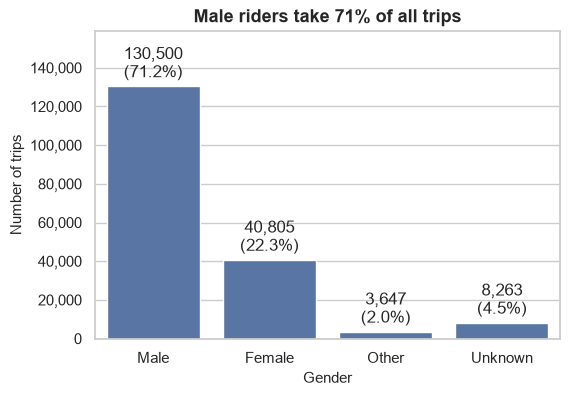

In [36]:
share = (df['member_gender'] == 'Male').mean()
count_bar(df['member_gender'], f'Male riders take {share:.0%} of all trips',
          'Gender', order=GENDER_ORDER)

**What we see:** Male riders take 130,500 trips (71.2%), Female riders 40,805 (22.3%), Other 3,647 (2.0%), and 8,263 trips (4.5%) have an unknown gender. Men make about 3.2 times as many trips as women.

**Why it matters:** The imbalance may reflect who signs up for the service and not who is willing to ride, and the data cannot tell these apart. Gender is self-reported, so we treat it with care.

### Q7. What is the distribution of trip duration in hours?

trips shorter than 1 hour: 99.07%
longest trip: 23.7 hours


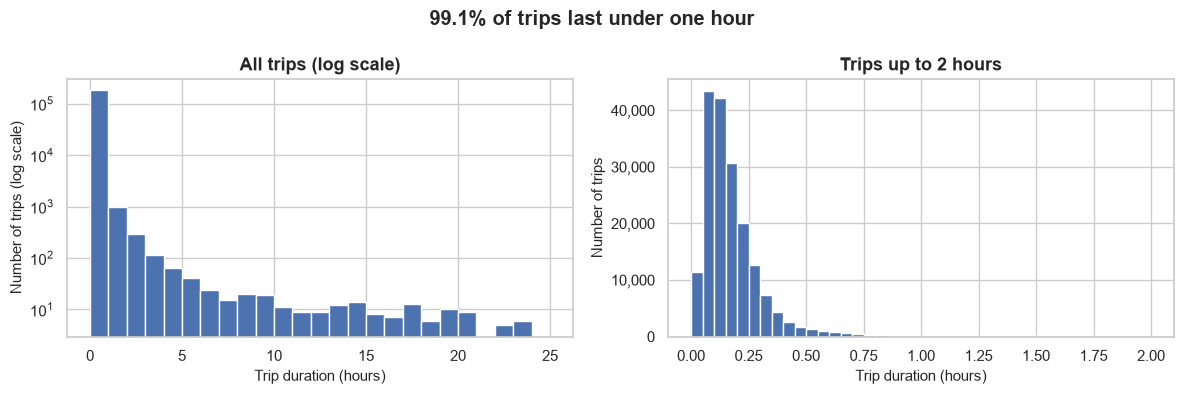

In [37]:
under_hour = (df['duration_hour'] < 1).mean()
print(f'trips shorter than 1 hour: {under_hour:.2%}')
print(f'longest trip: {df["duration_hour"].max():.1f} hours')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['duration_hour'], bins=range(0, 26), edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_title('All trips (log scale)')
axes[0].set_xlabel('Trip duration (hours)')
axes[0].set_ylabel('Number of trips (log scale)')

axes[1].hist(df['duration_hour'], bins=np.arange(0, 2.05, 0.05), edgecolor='white')
axes[1].set_title('Trips up to 2 hours')
axes[1].set_xlabel('Trip duration (hours)')
axes[1].set_ylabel('Number of trips')
axes[1].yaxis.set_major_formatter(thousands)

fig.suptitle(f'{under_hour:.1%} of trips last under one hour', fontweight='bold')
plt.tight_layout()
plt.show()

**What we see:** 99.1% of trips last less than one hour. Only 711 trips last more than two hours and 417 more than three hours. The log scale on the left shows how quickly the counts fall as duration grows.

**Why it matters:** Hours confirm what Q5 showed: almost every trip happens within the first hour, and very long trips are rare exceptions.

### Summary of the univariate findings

- **Riders:** 89% Subscribers, 71% men, median age 32.
- **Trips:** short and strongly right-skewed (median 8.6 minutes).
- **Problems found:** 72 impossible ages (above 100) and 417 trips longer than 3 hours. Both are treated next.

## Outlier Treatment

Q3 to Q5 found two kinds of outliers. We apply one clear rule to each, and the cleaning log records the effect.

| Variable | Rule | Trips affected | Action | Reason |
| :--- | :--- | :--- | :--- | :--- |
| Age | Above 100 years | 72 | Set age and birth year to unknown; **keep the trip** | The age is impossible, but the duration and stations of the trip are valid |
| Trip duration | Longer than 180 minutes (3 hours) | 417 (0.23%) | **Remove the trips** | Likely unreturned bikes or system errors; they would distort every average |

**Why not a statistical rule?** The interquartile-range rule would flag any trip longer than about 25 minutes, which is about 5.5% of the data. Most of these are ordinary leisure rides, so removing them would erase real behavior. The 99th percentile is used only to cap histograms, never to delete data.

In [38]:
# Rule 1: implausible ages become unknown. The trip stays, because its other fields are valid.
too_old = (df['age'] > MAX_AGE).fillna(False)
n_too_old = int(too_old.sum())
df.loc[too_old, 'age'] = pd.NA
df.loc[too_old, 'member_birth_year'] = np.nan
log_step(f'Age above {MAX_AGE} set to unknown', len(df), len(df),
         f'{n_too_old} implausible birth years (no trip removed)')

# Rule 2: trips longer than the limit are removed
rows_before = len(df)
df = df[df['duration_min'] <= MAX_DURATION_MIN].copy()
log_step(f'Remove trips longer than {MAX_DURATION_MIN} min', rows_before, len(df),
         'Likely unreturned bikes or system errors')

print(f'ages set to unknown: {n_too_old}')
print(f'trips removed for duration: {rows_before - len(df)}')
print(f'rows now: {len(df):,}')
print(f'trips with an unknown age: {df["age"].isna().sum():,}')

ages set to unknown: 72
trips removed for duration: 417
rows now: 182,798
trips with an unknown age: 8,248


### Cleaning Log

In [39]:
pd.DataFrame(cleaning_log)

,Step,Rows before,Rows after,Rows removed,Reason
0,Raw file loaded,-,"183,412",-,Initial dataset
1,Remove duplicate rows,"183,412","183,412",0,Checked full-row duplicates; none found
2,Remove trips without a station,"183,412","183,215",197,Missing essential station data
3,Age above 100 set to unknown,"183,215","183,215",0,72 implausible birth years (no trip removed)
4,Remove trips longer than 180 min,"183,215","182,798",417,Likely unreturned bikes or system errors


**Result:** 182,798 trips (99.7% of the raw file) are kept. Only 614 trips were removed: 197 without a station and 417 that lasted more than three hours. From this point on, every number describes these 182,798 trips.

## Additional Features

With the data cleaned, we add four features for the rest of the analysis and for the dashboard.

In [40]:
# Age groups (unknown ages get their own group)
df['age_group'] = pd.cut(df['age'].astype('float'), bins=[0, 29, 49, MAX_AGE],
                         labels=['Young', 'Adult', 'Senior'])
df['age_group'] = df['age_group'].cat.add_categories('Unknown').fillna('Unknown')
df['age_group'] = df['age_group'].astype(pd.CategoricalDtype(AGE_GROUP_ORDER, ordered=True))

# Round trips start and end at the same station
df['is_round_trip'] = df['start_station_id'] == df['end_station_id']

# Straight-line distance between the start and end station
df['distance_km'] = haversine_km(df['start_station_latitude'], df['start_station_longitude'],
                                 df['end_station_latitude'], df['end_station_longitude']).round(3)

# Rough region of the trip start, from the station coordinates
df['region'] = np.select([df['start_station_latitude'] < 37.5, df['start_station_longitude'] > -122.33],
                         ['San Jose', 'East Bay'], default='San Francisco')

display(df['age_group'].value_counts().to_frame('trips'))
print('round trips:', f"{df['is_round_trip'].sum():,} ({df['is_round_trip'].mean():.1%})")
display(df['region'].value_counts(normalize=True).round(3).to_frame('share of trips'))
df['distance_km'].describe().round(2).to_frame('km')

,trips
age_group,
Adult,93177
Young,65197
Senior,16176
Unknown,8248


round trips: 3,746 (2.0%)


,share of trips
region,
San Francisco,0.730
East Bay,0.226
San Jose,0.044


,km
count,182798.00
mean,1.69
std,1.10
min,0.00
25%,0.91
50%,1.43
75%,2.23
max,69.47


| Feature | Definition | Result |
| :--- | :--- | :--- |
| `age_group` | Young (18-29), Adult (30-49), Senior (50-100), Unknown | Adult 93,177 (51.0%), Young 65,197 (35.7%), Senior 16,176 (8.8%), Unknown 8,248 (4.5%) |
| `is_round_trip` | The trip starts and ends at the same station | 3,746 trips (2.0%) |
| `distance_km` | Straight-line distance between the start and end stations | Median 1.43 km, mean 1.69 km |
| `region` | San Francisco, East Bay or San Jose, from the start coordinates (a rough rule) | 73% San Francisco, 23% East Bay, 4% San Jose |

Straight-line distance is shorter than the real riding distance, so we use it to compare trips and not as an exact measure.

## Bivariate Exploration

Now we compare two variables at a time. From here on we use the cleaned data (182,798 trips).

### Q8. What is the average trip duration for each user type?

,count,mean,median
user_type,,,
Subscriber,163230,10.10,8.17
Customer,19568,18.52,13.05


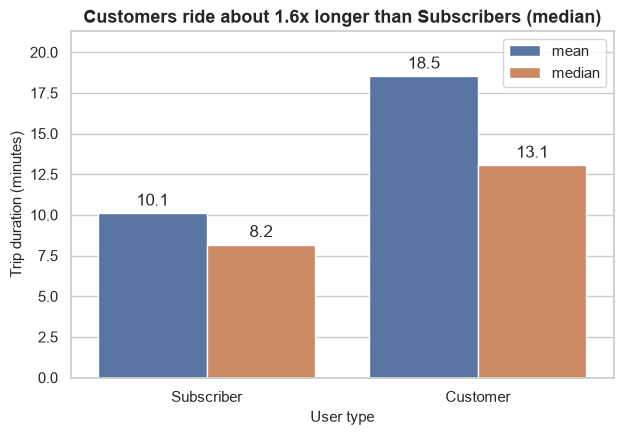

In [41]:
duration_by_type = (df.groupby('user_type', observed=True)['duration_min']
                      .agg(['count', 'mean', 'median']).reindex(USER_ORDER).round(2))
display(duration_by_type)

plot_data = (duration_by_type[['mean', 'median']].reset_index()
             .melt(id_vars='user_type', var_name='statistic', value_name='minutes'))
ratio = duration_by_type.loc['Customer', 'median'] / duration_by_type.loc['Subscriber', 'median']

plt.figure(figsize=(7, 4.5))
ax = sns.barplot(data=plot_data, x='user_type', y='minutes', hue='statistic')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)
ax.set_title(f'Customers ride about {ratio:.1f}x longer than Subscribers (median)')
ax.set_xlabel('User type')
ax.set_ylabel('Trip duration (minutes)')
ax.set_ylim(0, plot_data['minutes'].max() * 1.15)
ax.legend(title='')
plt.show()

**What we see:** Customers ride for 18.5 minutes on average (median about 13 minutes), Subscribers for 10.1 minutes (median 8.2). Customer trips are 1.8 times longer by the mean and 1.6 times longer by the median.

**Why it matters:** The gap is larger for the mean because rare very long trips affect Customers more, so the median is the fairer comparison. A possible explanation (a hypothesis, not proven by this data) is that Customers ride more for leisure: 28% of their trips are on weekends, against 15% for Subscribers.

### Q9. How long are trips for each gender?

,count,median,mean
member_gender,,,
Male,130301,8.2,10.5
Female,40700,9.4,11.8
Other,3621,9.2,12.4
Unknown,8176,10.0,14.9


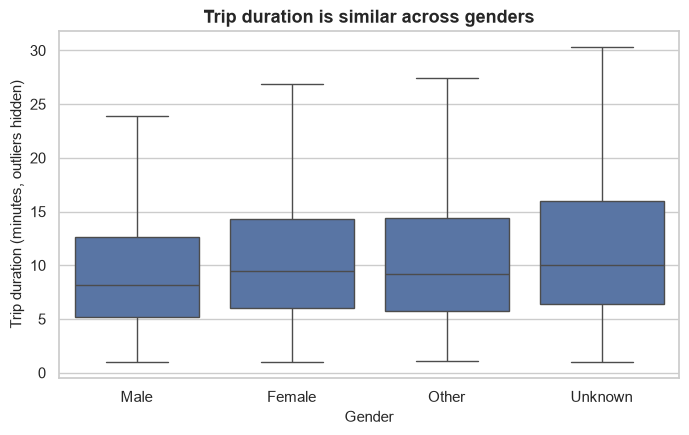

In [42]:
display(df.groupby('member_gender', observed=True)['duration_min']
         .agg(['count', 'median', 'mean']).reindex(GENDER_ORDER).round(1))

plt.figure(figsize=(8, 4.5))
sns.boxplot(data=df, x='member_gender', y='duration_min', order=GENDER_ORDER,
            showfliers=False, color='#4c72b0')
plt.title('Trip duration is similar across genders')
plt.xlabel('Gender')
plt.ylabel('Trip duration (minutes, outliers hidden)')
plt.show()

**What we see:** The median trip lasts 8.2 minutes for men, 9.4 for women, 9.2 for the group *Other* and 10.0 for unknown gender. Women's trips are about 15% longer than men's, a difference of roughly one minute, and the boxes overlap heavily.

**Why it matters:** Gender is at most a weak predictor of duration. The *Unknown* group has the longest trips (mean 14.9 minutes), but 38.6% of its trips are made by Customers, against 10.7% overall, so user type and not gender is the likely reason.

### Q10. How is trip duration distributed for each user type?

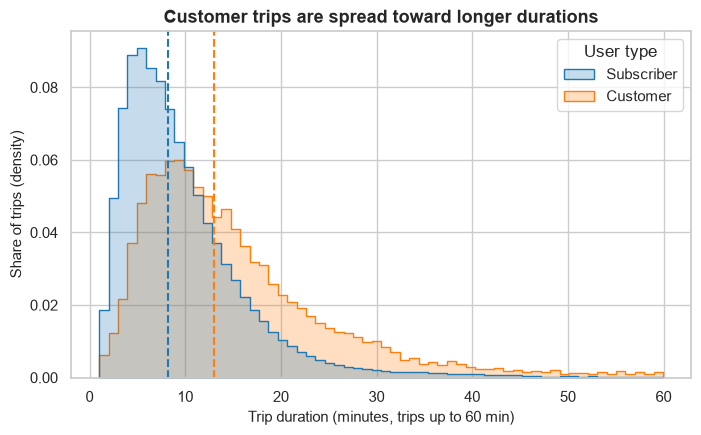

dashed lines = medians: {'Customer': 13.0, 'Subscriber': 8.2}


In [43]:
within_hour = df[df['duration_min'] <= 60]
medians = df.groupby('user_type', observed=True)['duration_min'].median()

plt.figure(figsize=(8, 4.5))
ax = sns.histplot(data=within_hour, x='duration_min', hue='user_type', hue_order=USER_ORDER,
                  palette=USER_COLORS, stat='density', common_norm=False,
                  element='step', bins=60)
for user_type, value in medians.items():
    ax.axvline(value, color=USER_COLORS[user_type], linestyle='--')
ax.set_title('Customer trips are spread toward longer durations')
ax.set_xlabel('Trip duration (minutes, trips up to 60 min)')
ax.set_ylabel('Share of trips (density)')
ax.get_legend().set_title('User type')
plt.show()

print('dashed lines = medians:', medians.round(1).to_dict())

**What we see:** Q8 compared averages. This chart shows the full shape. The most common Subscriber trip lasts about 5 to 6 minutes, and 62.4% of Subscriber trips are 10 minutes or shorter. The most common Customer trip lasts about 8 to 9 minutes, and only 34.5% are 10 minutes or shorter. 26.3% of Customer trips last more than 20 minutes, against 7.3% of Subscriber trips.

**Why it matters:** Customers are not just slightly slower. Their distribution is shifted and has a much heavier tail of long rides.

### Q11. How do age and user type relate?

,count,mean,std,min,25%,50%,75%,max
user_type,,,,,,,,
Subscriber,158140.0,34.2,10.0,18.0,27.0,32.0,39.0,99.0
Customer,16410.0,33.6,9.4,18.0,27.0,32.0,38.0,91.0


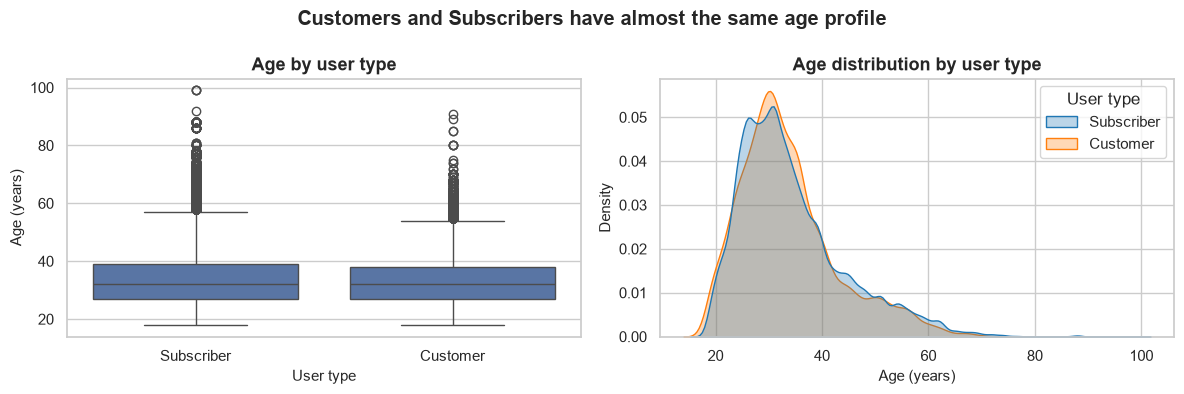

In [44]:
known_age = df.dropna(subset=['age']).assign(age=lambda d: d['age'].astype(int))
display(known_age.groupby('user_type', observed=True)['age'].describe().reindex(USER_ORDER).round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=known_age, x='user_type', y='age', order=USER_ORDER, color='#4c72b0', ax=axes[0])
axes[0].set_title('Age by user type')
axes[0].set_xlabel('User type')
axes[0].set_ylabel('Age (years)')

sns.kdeplot(data=known_age, x='age', hue='user_type', hue_order=USER_ORDER, palette=USER_COLORS,
            common_norm=False, fill=True, alpha=0.3, ax=axes[1])
axes[1].set_title('Age distribution by user type')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Density')
axes[1].get_legend().set_title('User type')

fig.suptitle('Customers and Subscribers have almost the same age profile', fontweight='bold')
plt.tight_layout()
plt.show()

**What we see:** Both user types have the same median age (32) and almost the same spread: the middle half of Subscribers is 27 to 39 years old, and 27 to 38 for Customers. The mean ages are 34.2 and 33.6.

**Why it matters:** Age does not separate Customers from Subscribers, so the duration gap found in Q8 is not caused by age. One caution: 16.1% of Customer trips have no age, against 3.1% of Subscriber trips, so the Customer curve rests on fewer trips.

### Q12. How do age and gender relate?

,count,mean,std,min,25%,50%,75%,max
member_gender,,,,,,,,
Male,130244.0,34.4,10.2,18.0,27.0,32.0,39.0,99.0
Female,40686.0,33.2,9.1,18.0,27.0,31.0,37.0,86.0
Other,3620.0,35.9,10.0,19.0,29.0,34.0,40.0,91.0


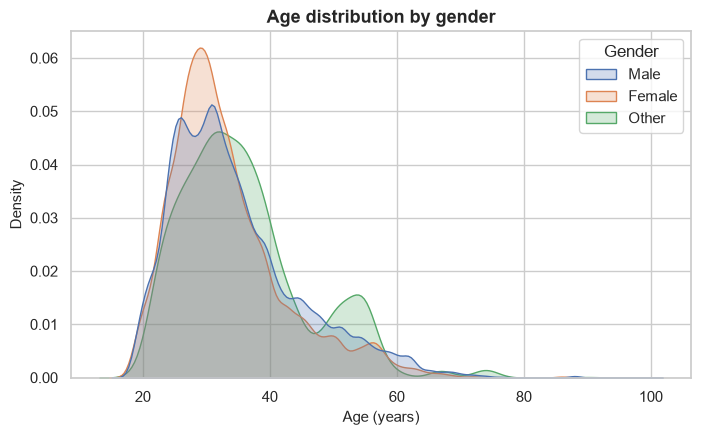

In [45]:
gender_known = known_age[known_age['member_gender'].isin(['Male', 'Female', 'Other'])]
display(gender_known.groupby('member_gender', observed=True)['age']
        .describe().reindex(['Male', 'Female', 'Other']).round(1))

plt.figure(figsize=(8, 4.5))
sns.kdeplot(data=gender_known, x='age', hue='member_gender', hue_order=['Male', 'Female', 'Other'],
            common_norm=False, fill=True, alpha=0.25)
plt.title('Age distribution by gender')
plt.xlabel('Age (years)')
plt.ylabel('Density')
plt.gca().get_legend().set_title('Gender')
plt.show()

**What we see:** Women are slightly younger (median 31, mean 33.2) than men (median 32, mean 34.4). Riders in the group *Other* are older (median 34), but there are only 3,620 of them, so their curve is noisy. All three groups are concentrated in the late 20s and the 30s.

**Why it matters:** The age difference between genders is small (one year at the median) and does not change the overall picture.

### Summary of the bivariate findings

- **User type** is the strongest separator: Customers ride about 1.6 times longer than Subscribers.
- **Gender** has a small effect on duration (about one minute).
- **Age** has no visible effect on duration or on user type.

## Multivariate Exploration

Here we study three or more variables together, starting with correlations. We use the Spearman correlation, because duration is heavily skewed and Spearman does not assume a straight-line relationship. It ranges from -1 to 1, and values near 0 mean no relationship.

### Q13. What is the correlation between all numeric variables?

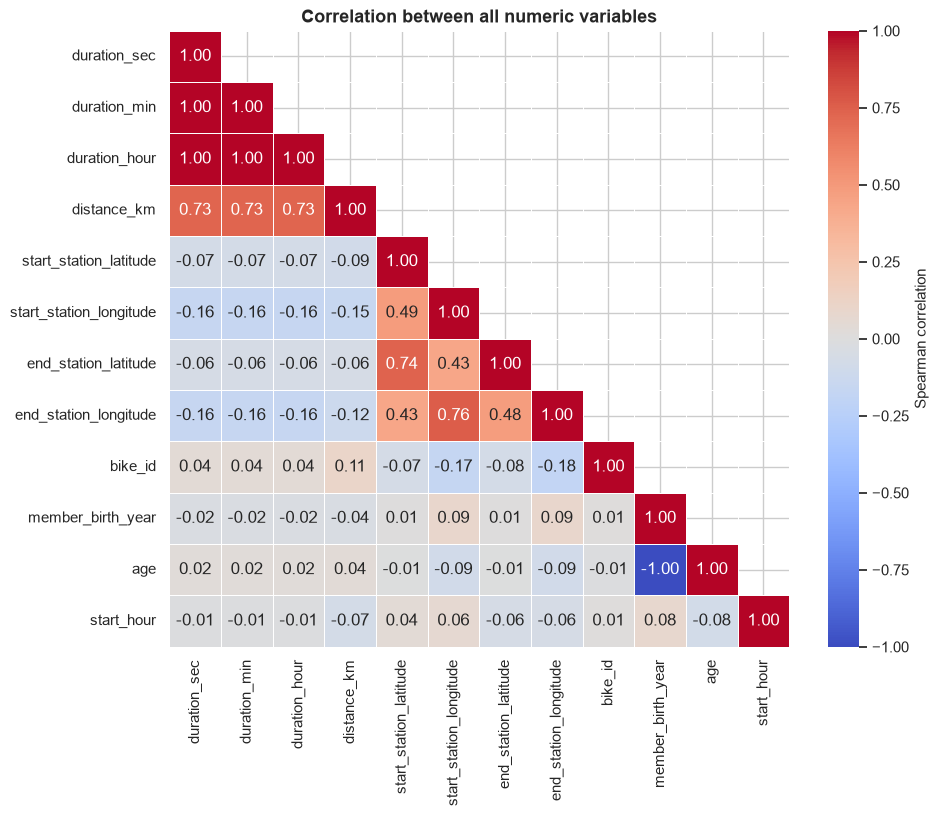

In [46]:
numeric_cols = ['duration_sec', 'duration_min', 'duration_hour', 'distance_km',
                'start_station_latitude', 'start_station_longitude',
                'end_station_latitude', 'end_station_longitude',
                'bike_id', 'member_birth_year', 'age', 'start_hour']

# Spearman is used because duration is heavily skewed
corr_all = df[numeric_cols].astype(float).corr(method='spearman')
mask = np.triu(np.ones_like(corr_all, dtype=bool), k=1)   # hide the upper triangle, keep the diagonal

plt.figure(figsize=(10, 8))
sns.heatmap(corr_all, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'Spearman correlation'})
plt.title('Correlation between all numeric variables')
plt.show()

In [47]:
# Why is duration weakly related to longitude? Trip length differs by region.
df.groupby('region')['duration_min'].agg(['count', 'median']).round(2)

,count,median
region,,
East Bay,41357,6.68
San Francisco,133377,9.28
San Jose,8064,7.04


**What we see:**

- **Repeated information.** `duration_sec`, `duration_min` and `duration_hour` correlate at 1.00 because they are the same measure in different units. Age and birth year correlate at -1.00 for the same reason.
- **The strongest real relationship** is between duration and straight-line distance (0.73).
- **Start and end coordinates** correlate strongly (0.74 for latitude, 0.76 for longitude): trips are short, so they end near where they start.
- **Duration and start longitude** have a weak negative correlation (-0.16). The table shows why: trips in San Francisco are longer (median 9.3 minutes) than in the East Bay (6.7) or San Jose (7.0).
- **Near zero:** age (0.02) and start hour (-0.01). `bike_id` is only an identifier, so its correlations mean nothing.

**Why it matters:** Before modeling, we should drop the repeated columns and the identifier.

### Q14. What relationships exist between the main numeric variables?

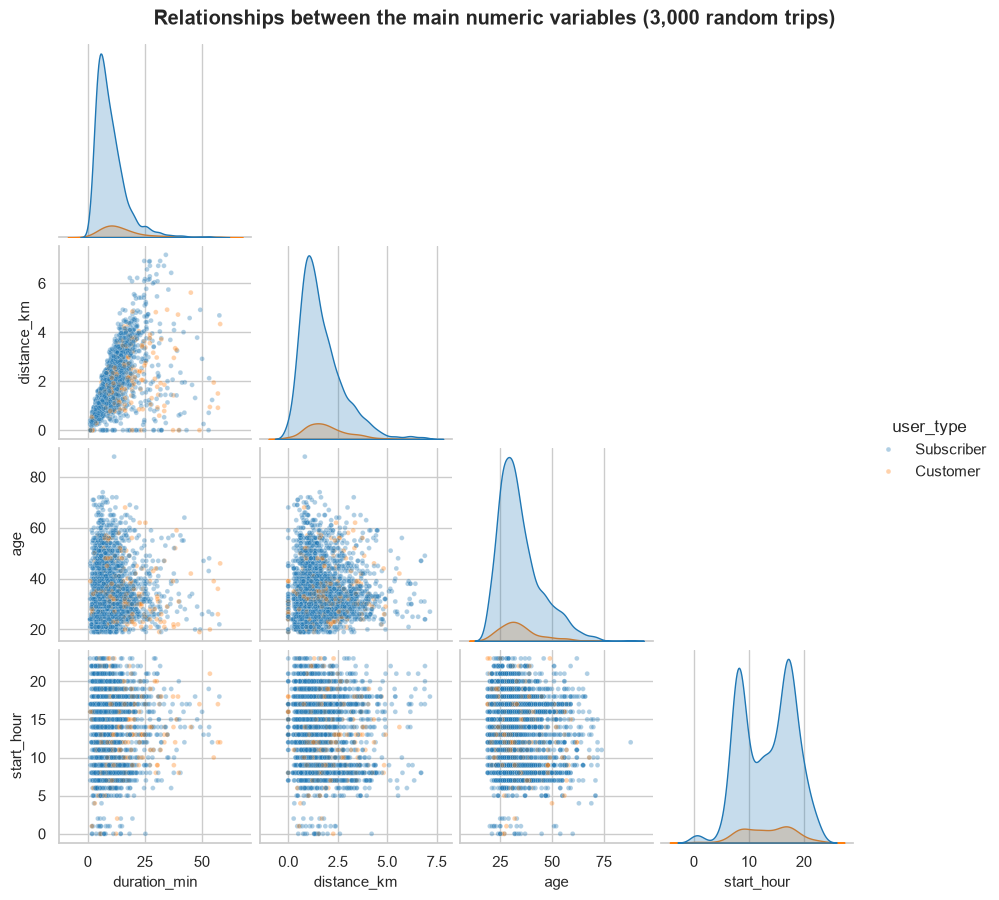

In [48]:
# A random sample keeps the plot readable; trips up to 60 minutes cover about 99% of the data
sample = (df[(df['duration_min'] <= 60) & df['age'].notna()]
          .sample(3000, random_state=42)
          .assign(age=lambda d: d['age'].astype(float)))

g = sns.pairplot(sample, vars=['duration_min', 'distance_km', 'age', 'start_hour'],
                 hue='user_type', hue_order=USER_ORDER, palette=USER_COLORS,
                 corner=True, plot_kws={'alpha': 0.35, 's': 12}, height=2.2)
g.figure.suptitle('Relationships between the main numeric variables (3,000 random trips)', y=1.02,
                  fontweight='bold')
plt.show()

**What we see:** Duration rises with distance, but with a wide spread: some riders take much longer than the distance suggests (they may stop, sightsee or ride slowly). Age shows no pattern against duration or distance. The start hour has two peaks, near 8:00 and 17:00. Customers (orange) are only about 10% of the trips, so they appear as fewer points.

**Why it matters:** Only duration and distance are clearly related. The two rush-hour peaks show that commuting shapes when trips start.

### Q15. What is the correlation between the variables of interest?

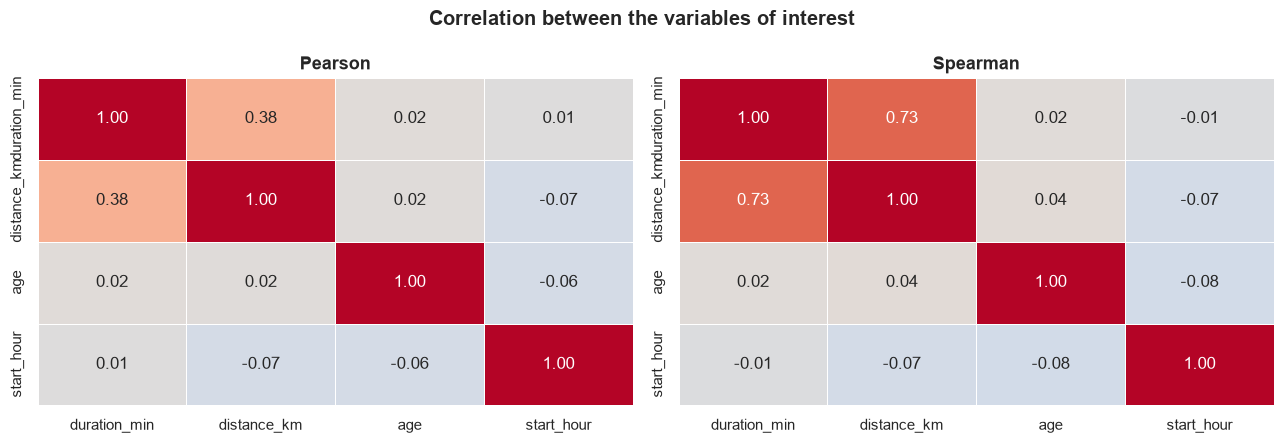

In [49]:
focus = ['duration_min', 'distance_km', 'age', 'start_hour']
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, method in zip(axes, ['pearson', 'spearman']):
    corr = df[focus].astype(float).corr(method=method)
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
                linewidths=0.5, cbar=False, ax=ax)
    ax.set_title(method.capitalize())

fig.suptitle('Correlation between the variables of interest', fontweight='bold')
plt.tight_layout()
plt.show()

**What we see:** The Pearson correlation between duration and distance is 0.38, while the Spearman correlation is 0.73. Every other pair is close to zero: age and duration 0.02, distance and start hour -0.07, age and start hour -0.08 (Spearman).

**Why it matters:** A large gap between Pearson and Spearman means the relationship is consistent but not a straight line, which is expected with a long tail of slow or long trips. Spearman is the more reliable measure here.

### Q16. How does trip duration vary by user type and age group?

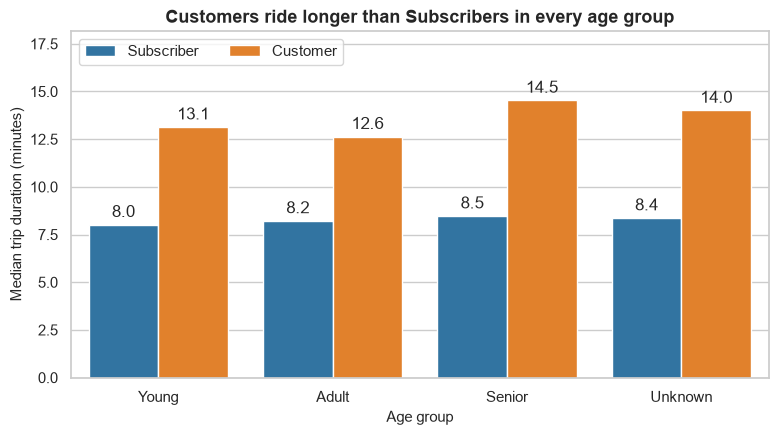

In [50]:
duration_group = (df.groupby(['age_group', 'user_type'], observed=True)['duration_min']
                  .median().reset_index())

plt.figure(figsize=(9, 4.5))
ax = sns.barplot(data=duration_group, x='age_group', y='duration_min', order=AGE_GROUP_ORDER,
                 hue='user_type', hue_order=USER_ORDER, palette=USER_COLORS)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)
ax.set_title('Customers ride longer than Subscribers in every age group')
ax.set_xlabel('Age group')
ax.set_ylabel('Median trip duration (minutes)')
ax.set_ylim(0, duration_group['duration_min'].max() * 1.25)
ax.legend(title='', loc='upper left', ncol=2)
plt.show()

**What we see:** Customers ride longer than Subscribers in every age group. The median is 13.1 vs 8.0 minutes for Young riders, 12.6 vs 8.2 for Adults, 14.5 vs 8.5 for Seniors and 14.0 vs 8.4 for Unknown ages. The Customer median is 1.5 to 1.7 times the Subscriber median. Among Subscribers the median stays between 8.0 and 8.5 minutes in every age group, and among Customers it stays between 12.6 and 14.5 minutes without a consistent trend by age.

**Why it matters:** This is a three-variable check of Q8 and Q11. User type explains the duration difference, and age does not.

## Time Analysis

When do people ride? The brief asks for trips by weekday, by day and by hour.

### T1. How many trips are made on each day of the week?

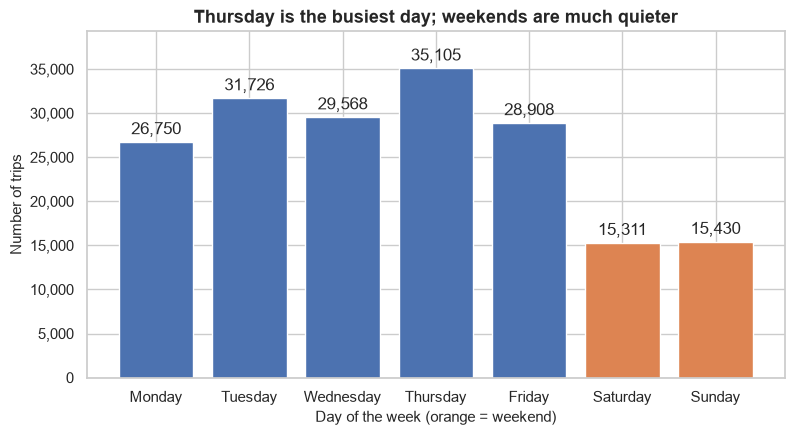

In [51]:
weekday_counts = df['day_of_week'].value_counts().sort_index()
busiest = weekday_counts.idxmax()

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(weekday_counts.index.astype(str), weekday_counts.values,
              color=['#4c72b0'] * 5 + ['#dd8452'] * 2)
ax.bar_label(bars, labels=[f'{v:,}' for v in weekday_counts.values], padding=3)
ax.set_title(f'{busiest} is the busiest day; weekends are much quieter')
ax.set_xlabel('Day of the week (orange = weekend)')
ax.set_ylabel('Number of trips')
ax.set_ylim(0, weekday_counts.max() * 1.12)
ax.yaxis.set_major_formatter(thousands)
plt.show()

**What we see:** Thursday is the busiest day (35,105 trips), followed by Tuesday (31,726) and Wednesday (29,568). Saturday (15,311) and Sunday (15,430) are the quietest. February 2019 has exactly four of each weekday, so the counts compare fairly. An average weekday has about 7,600 trips and an average weekend day about 3,800.

**Why it matters:** Weekends are 2 of 7 days (28.6%) but only 16.8% of the trips. A weekday has about twice the trips of a weekend day, which points to commuting as the main use.

### T2. How did daily trips change during the month?

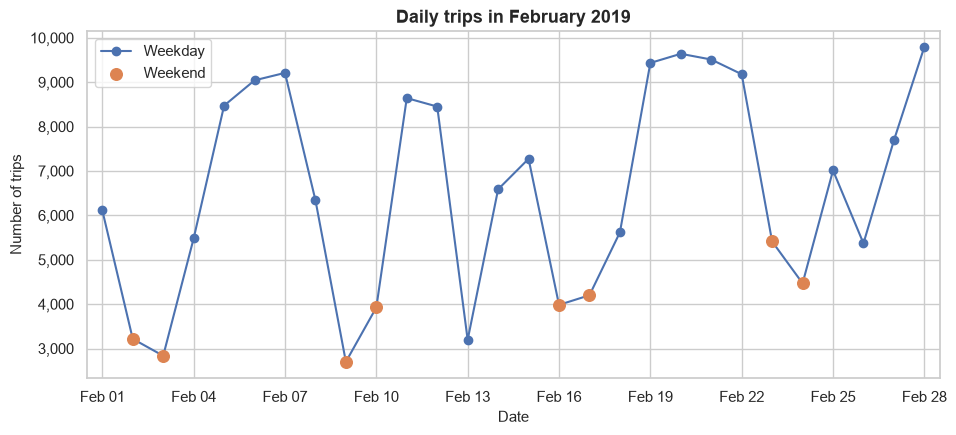

busiest day : 2019-02-28 (9,797 trips)
quietest day: 2019-02-09 (2,700 trips)


In [52]:
import matplotlib.dates as mdates

daily = df.groupby('start_date').size()
weekend_days = daily[daily.index.dayofweek >= 5]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(daily.index, daily.values, marker='o', color='#4c72b0', label='Weekday')
ax.scatter(weekend_days.index, weekend_days.values, color='#dd8452', s=70, zorder=3, label='Weekend')
ax.xaxis.set_major_locator(mdates.DayLocator(bymonthday=range(1, 29, 3)))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.set_xlim(daily.index.min() - pd.Timedelta(hours=12), daily.index.max() + pd.Timedelta(hours=12))
ax.set_title('Daily trips in February 2019')
ax.set_xlabel('Date')
ax.set_ylabel('Number of trips')
ax.yaxis.set_major_formatter(thousands)
ax.legend()
plt.show()

print('busiest day :', daily.idxmax().date(), f'({daily.max():,} trips)')
print('quietest day:', daily.idxmin().date(), f'({daily.min():,} trips)')

**What we see:** The chart shows a weekly rhythm with the lows on weekends. The busiest day was Thursday, February 28 (9,797 trips), followed by Wednesday 20 (9,640) and Thursday 21 (9,511). The quietest were Saturday, February 9 (2,700) and Sunday, February 3 (2,836). Some weekdays are unusually quiet: Wednesday, February 13 had only 3,195 trips, about the level of a weekend day.

**Why it matters:** The dataset has no weather information, so we cannot explain the quiet weekdays. Weather is a plausible hypothesis that could be tested with external data.

### T3. At what hours are bikes used on each day?

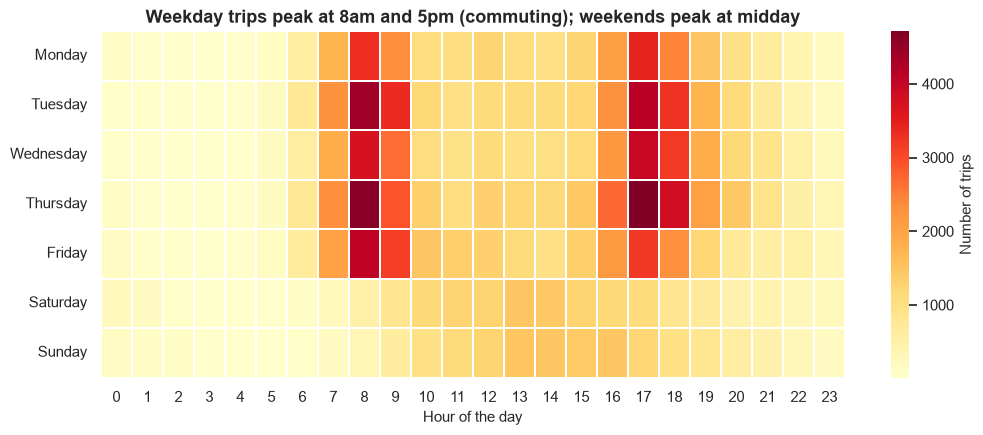

busiest hour-slot: Thursday at 17:00 (4,715 trips)


In [53]:
hour_day = pd.crosstab(df['day_of_week'], df['start_hour']).reindex(DAY_ORDER)

plt.figure(figsize=(12, 4.5))
sns.heatmap(hour_day, cmap='YlOrRd', linewidths=0.3, cbar_kws={'label': 'Number of trips'})
plt.title('Weekday trips peak at 8am and 5pm (commuting); weekends peak at midday')
plt.xlabel('Hour of the day')
plt.ylabel('')
plt.show()

top = hour_day.stack().idxmax()
print(f'busiest hour-slot: {top[0]} at {top[1]}:00 ({hour_day.stack().max():,} trips)')

**What we see:** Monday to Friday show two clear peaks at 8:00 and 17:00. 59.6% of weekday trips start between 7:00 and 9:59 or between 16:00 and 18:59. The busiest slot of the week is Thursday at 17:00 (4,715 trips). On weekends the pattern is a single broad peak around 13:00 (9.6% of weekend trips), and 52.6% of weekend trips start between 11:00 and 16:59. Trips between midnight and 5:00 are rare on every day.

**Why it matters:** The system is used for commuting on weekdays and for leisure on weekends. Bike availability matters most in the morning and evening rush hours.

### T4. Do Subscribers and Customers ride at different times?

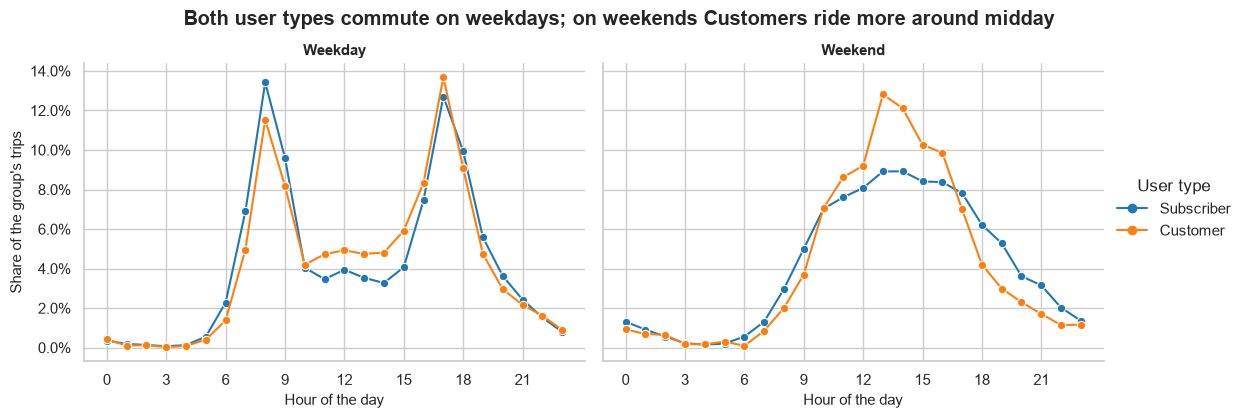

In [54]:
hourly = (df.assign(day_type=np.where(df['is_weekend'], 'Weekend', 'Weekday'))
            .groupby(['day_type', 'user_type', 'start_hour'], observed=True)
            .size().reset_index(name='trips'))
# Share of each group's trips, so the two user types can be compared fairly
hourly['share'] = hourly['trips'] / hourly.groupby(['day_type', 'user_type'])['trips'].transform('sum')

g = sns.relplot(data=hourly, x='start_hour', y='share', hue='user_type', hue_order=USER_ORDER,
                palette=USER_COLORS, col='day_type', col_order=['Weekday', 'Weekend'],
                kind='line', marker='o', height=4, aspect=1.4)
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_xticks(range(0, 24, 3))
g.set_axis_labels('Hour of the day', 'Share of the group\'s trips')
g.set_titles('{col_name}')
g._legend.set_title('User type')
g.figure.suptitle('Both user types commute on weekdays; on weekends Customers ride more around midday',
                  y=1.04, fontweight='bold')
plt.show()

**What we see:** This chart combines four variables: hour, weekday or weekend, user type and share of trips.

- **On weekdays** both groups follow the commute pattern. 60.0% of Subscriber trips and 55.8% of Customer trips start in the rush windows (7:00-9:59 and 16:00-18:59). Customers ride somewhat more in between: 33.5% of their weekday trips start between 11:00 and 16:59, against 25.7% for Subscribers.
- **On weekends** Customers concentrate around midday. 62.9% of their weekend trips start between 11:00 and 16:59 (peak 12.8% at 13:00), against 50.3% for Subscribers.
- **Weekends matter more for Customers:** 28.2% of their trips happen on weekends, against 15.5% for Subscribers.

**Why it matters:** Customers also show clear commute peaks, so their use is not only leisure. Still, their weekend and midday use is stronger than that of Subscribers, which is useful for planning offers such as weekend passes.

## User Analysis

Who rides? We add the age groups defined earlier.

### U1. How do age groups differ in volume, duration and user type?

,trips,median_duration,customer_share
age_group,,,
Young,65197,8.350,0.092
Adult,93177,8.533,0.097
Senior,16176,8.783,0.083
Unknown,8248,10.000,0.383


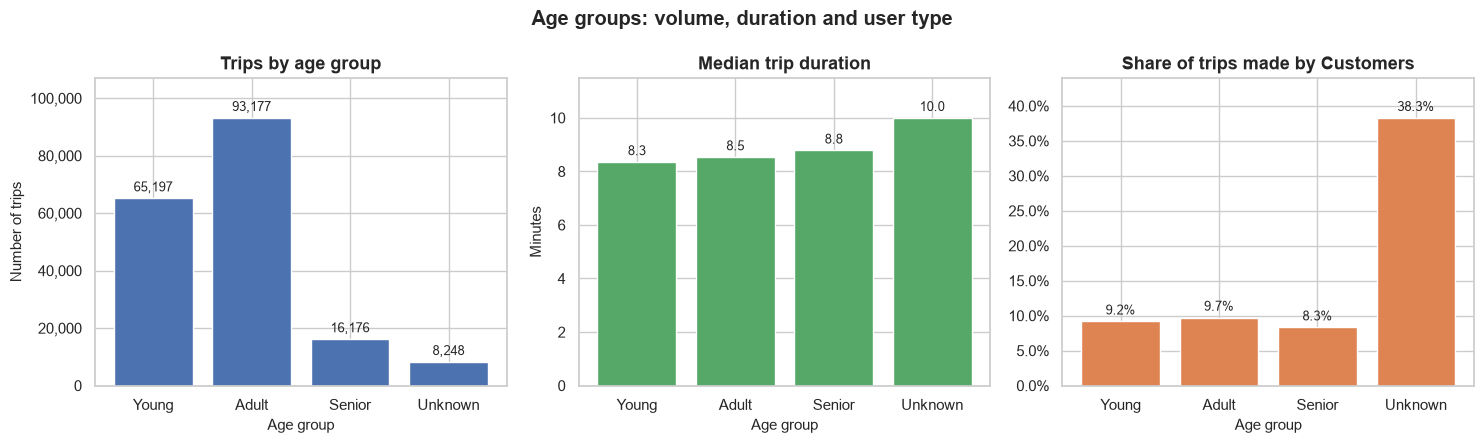

In [55]:
age_group_stats = (df.groupby('age_group', observed=True)
                     .agg(trips=('duration_min', 'size'), median_duration=('duration_min', 'median'))
                     .reindex(AGE_GROUP_ORDER))
customer_share = (pd.crosstab(df['age_group'], df['user_type'], normalize='index')['Customer']
                  .reindex(AGE_GROUP_ORDER))
display(age_group_stats.assign(customer_share=customer_share).round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

bars = axes[0].bar(AGE_GROUP_ORDER, age_group_stats['trips'], color='#4c72b0')
axes[0].bar_label(bars, labels=[f'{v:,}' for v in age_group_stats['trips']], padding=3, fontsize=9)
axes[0].set_title('Trips by age group')
axes[0].set_ylabel('Number of trips')
axes[0].set_ylim(0, age_group_stats['trips'].max() * 1.15)
axes[0].yaxis.set_major_formatter(thousands)

bars = axes[1].bar(AGE_GROUP_ORDER, age_group_stats['median_duration'], color='#55a868')
axes[1].bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
axes[1].set_title('Median trip duration')
axes[1].set_ylabel('Minutes')
axes[1].set_ylim(0, age_group_stats['median_duration'].max() * 1.15)

bars = axes[2].bar(AGE_GROUP_ORDER, customer_share, color='#dd8452')
axes[2].bar_label(bars, labels=[f'{v:.1%}' for v in customer_share], padding=3, fontsize=9)
axes[2].set_title('Share of trips made by Customers')
axes[2].yaxis.set_major_formatter(PercentFormatter(1))
axes[2].set_ylim(0, customer_share.max() * 1.15)

for ax in axes:
    ax.set_xlabel('Age group')
fig.suptitle('Age groups: volume, duration and user type', fontweight='bold')
plt.tight_layout()
plt.show()

**What we see:** Adults (30-49) make half of all trips (93,177; 51.0%), followed by Young riders (65,197; 35.7%) and Seniors (16,176; 8.8%). 8,248 trips (4.5%) have an unknown age. The median trip duration rises only slightly with age (from about 8.3 to 8.8 minutes). Customers make 8.3% to 9.7% of the trips in every known age group, but **38.3% of the trips with unknown age**.

**Why it matters:** The *Unknown* group is not a random leftover. It is largely made of casual riders: 16.1% of Customer trips have no age, against 3.1% of Subscriber trips. Anyone filtering the dashboard by age group should keep this in mind.

## Station and Route Analysis

Where do people ride? We look at the busiest stations, the balance between arrivals and departures, the most popular routes and the map.

### S1. Which stations are the busiest for starting and ending trips?

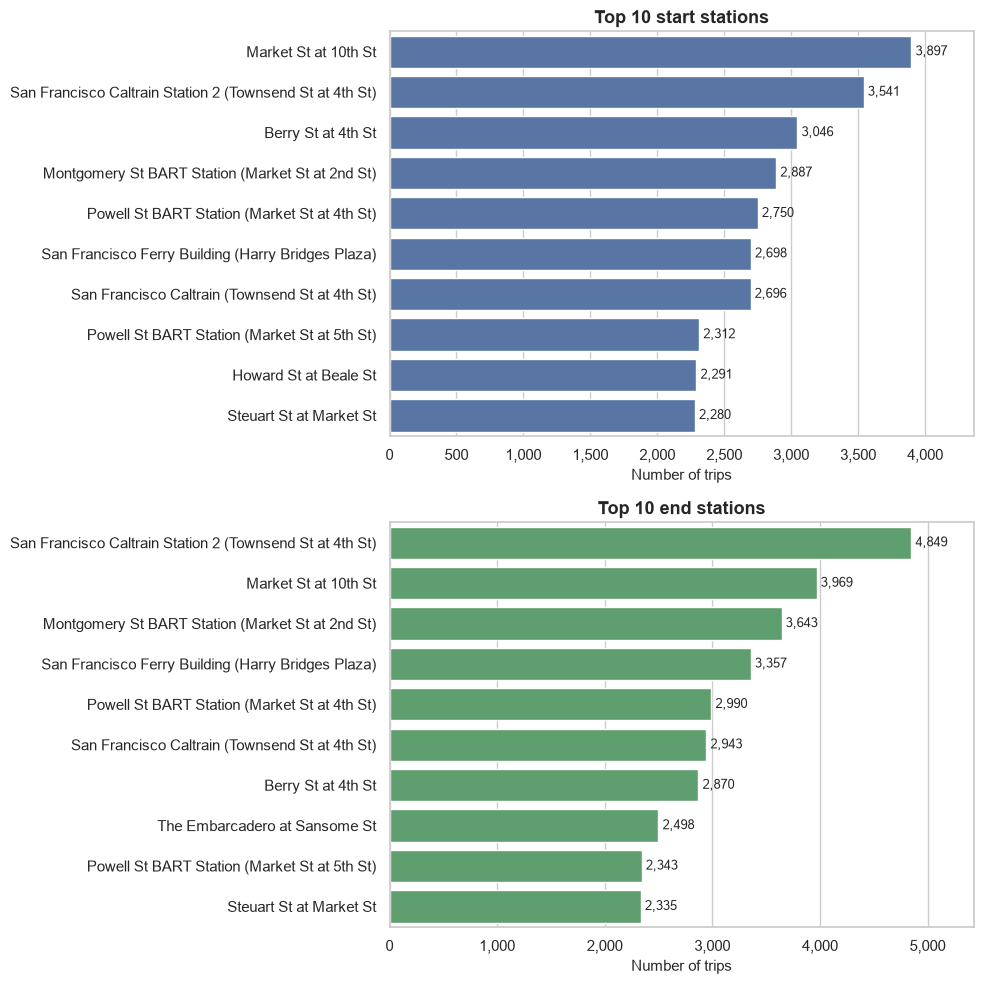

In [56]:
def station_counts(column):
    """Number of trips per station, with names and coordinates."""
    return (df[column].value_counts().rename_axis('id').reset_index(name='trips')
            .merge(stations, on='id'))


start_counts = station_counts('start_station_id')
end_counts = station_counts('end_station_id')

fig, axes = plt.subplots(2, 1, figsize=(10, 10))
for ax, data, title, color in [(axes[0], start_counts.head(10), 'Top 10 start stations', '#4c72b0'),
                               (axes[1], end_counts.head(10), 'Top 10 end stations', '#55a868')]:
    sns.barplot(data=data, y='name', x='trips', color=color, ax=ax)
    ax.bar_label(ax.containers[0], labels=[f'{v:,}' for v in data['trips']], padding=3, fontsize=9)
    ax.set_title(title)
    ax.set_xlabel('Number of trips')
    ax.set_ylabel('')
    ax.set_xlim(0, data['trips'].max() * 1.12)
    ax.xaxis.set_major_formatter(thousands)
plt.tight_layout()
plt.show()

**What we see:** Market St at 10th St is the busiest start station (3,897 trips, 2.1% of all trips), followed by San Francisco Caltrain Station 2 (3,541) and Berry St at 4th St (3,046). The Caltrain station is the busiest end station (4,849 trips, 2.7%). The ten busiest start stations account for 15.5% of all trips.

**Why it matters:** Demand concentrates along Market St and around transit hubs (Caltrain, BART and the Ferry Building), where riders connect to and from public transport.

### S2. Which stations gain or lose bikes?

In [57]:
# Arrivals minus departures for every station
net_flow = (end_counts.set_index('name')['trips']
            .sub(start_counts.set_index('name')['trips'], fill_value=0)
            .sort_values())
extremes = pd.concat([net_flow.head(3), net_flow.tail(3)]).astype(int)
extremes.to_frame('arrivals minus departures')

,arrivals minus departures
name,
Bancroft Way at College Ave,-643
Haste St at College Ave,-325
Howard St at Beale St,-258
San Francisco Ferry Building (Harry Bridges Plaza),659
Montgomery St BART Station (Market St at 2nd St),756
San Francisco Caltrain Station 2 (Townsend St at 4th St),1308


**What we see:** The San Francisco Caltrain Station 2 receives 1,308 more trips than it starts. Montgomery St BART (+756) and the Ferry Building (+659) follow. The largest deficits are at Bancroft Way at College Ave (-643) and Haste St at College Ave (-325) in the East Bay, and Howard St at Beale St (-258) in San Francisco.

**Why it matters:** Bikes accumulate at the commuter hubs and run short at the stations with more departures than arrivals. This gives the operator a clear list of stations to rebalance.

### S3. What are the most popular routes?

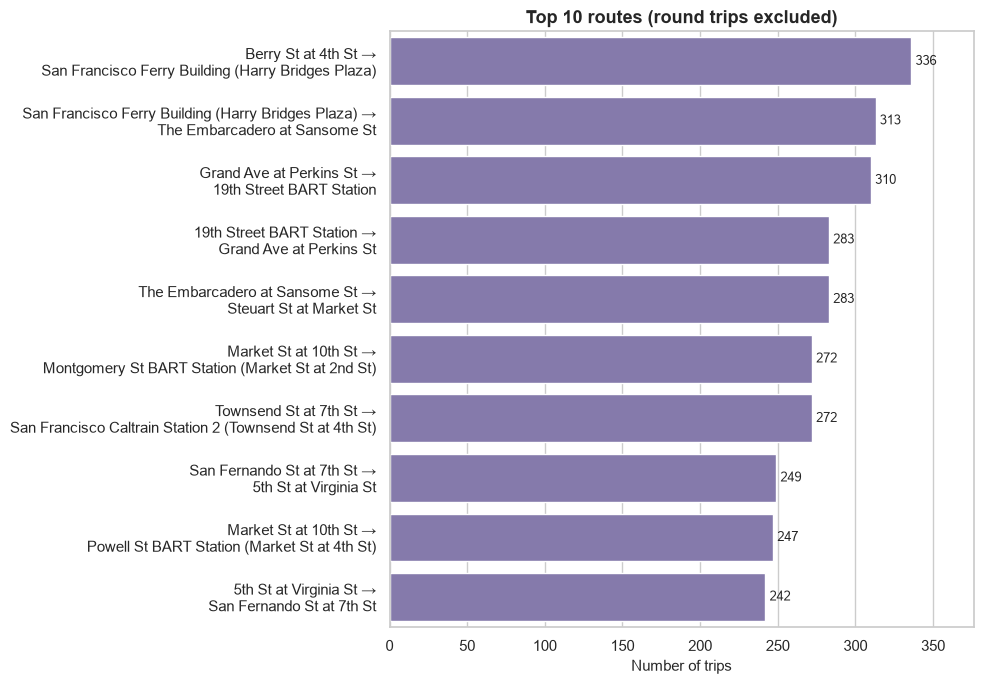

In [58]:
routes = (df[~df['is_round_trip']]
          .groupby(['start_station_name', 'end_station_name']).size()
          .reset_index(name='trips').nlargest(10, 'trips'))
routes['route'] = routes['start_station_name'] + ' \u2192\n' + routes['end_station_name']

plt.figure(figsize=(10, 7))
ax = sns.barplot(data=routes, y='route', x='trips', color='#8172b3')
ax.bar_label(ax.containers[0], labels=[f'{v:,}' for v in routes['trips']], padding=3, fontsize=9)
ax.set_title('Top 10 routes (round trips excluded)')
ax.set_xlabel('Number of trips')
ax.set_ylabel('')
ax.set_xlim(0, routes['trips'].max() * 1.12)
plt.tight_layout()
plt.show()

**What we see:** The busiest route is Berry St at 4th St to the Ferry Building (336 trips), followed by the Ferry Building to The Embarcadero at Sansome St (313) and Grand Ave at Perkins St to 19th Street BART (310). Routes tend to come in pairs: 19th Street BART to Grand Ave at Perkins St has 283 trips. Excluding round trips, there are 23,306 different routes, and no single route accounts for more than 0.2% of the trips.

**Why it matters:** Demand is spread across many routes, so planning at station level is more practical than planning at route level.

### S4. Where are the stations and how busy is each one?

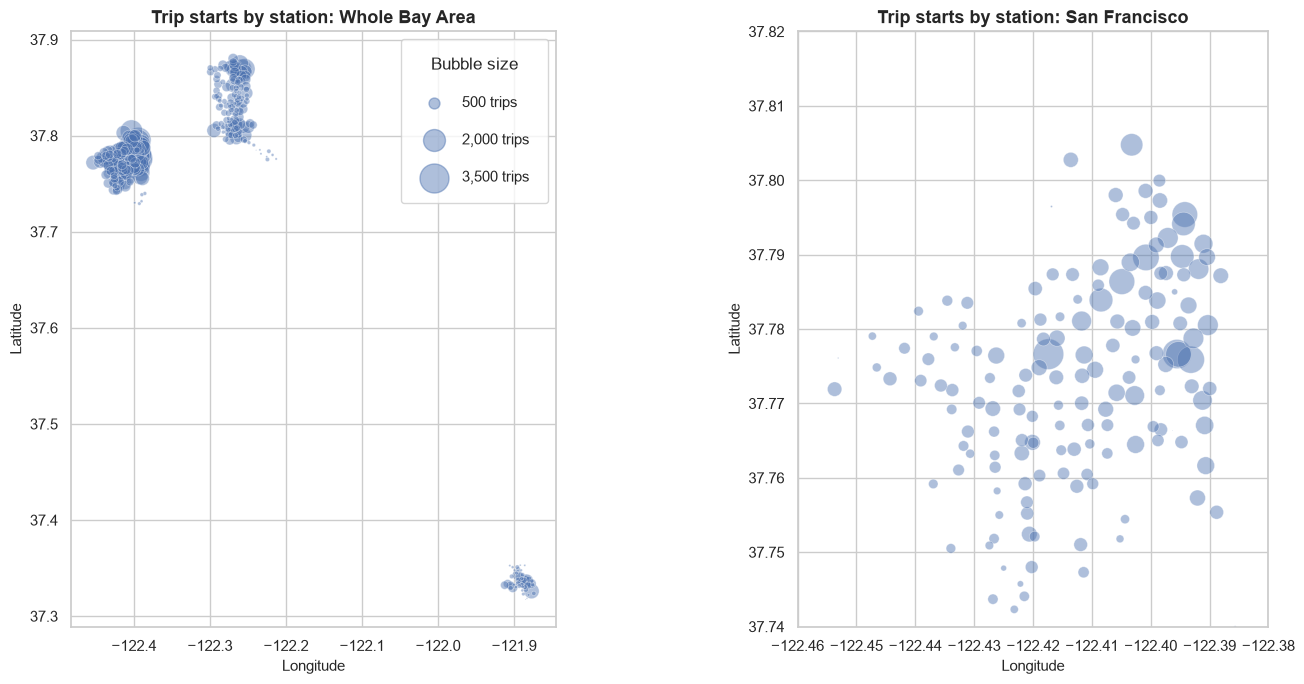

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
views = [('Whole Bay Area', None), ('San Francisco', (-122.46, -122.38, 37.74, 37.82))]

for ax, (title, limits) in zip(axes, views):
    ax.scatter(start_counts['lon'], start_counts['lat'], s=start_counts['trips'] / 8,
               alpha=0.45, color='#4c72b0', edgecolor='white', linewidth=0.5)
    ax.set_aspect(1 / np.cos(np.radians(37.7)))
    ax.set_title(f'Trip starts by station: {title}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    if limits:
        ax.set_xlim(limits[0], limits[1])
        ax.set_ylim(limits[2], limits[3])

for size in [500, 2000, 3500]:
    axes[0].scatter([], [], s=size / 8, color='#4c72b0', alpha=0.45, label=f'{size:,} trips')
axes[0].legend(title='Bubble size', loc='upper right', labelspacing=1.5, borderpad=1.2)
plt.tight_layout()
plt.show()

**What we see:** Stations form three clusters: San Francisco (73% of trip starts), the East Bay around Oakland and Berkeley (23%) and San Jose (4%). The largest bubbles are in downtown San Francisco, along Market St and the waterfront.

**Why it matters:** The stations form three geographically separate clusters. Trips also differ by region (Q13 showed a median of 9.3 minutes in San Francisco, against 6.7 in the East Bay), so a dashboard map should let users zoom into each cluster.

## Encoding and Scaling

Statistical models need numbers, and many of them also need columns on a similar scale. We prepare a model-ready table `df_model`:

| Step | Columns | Method |
| :--- | :--- | :--- |
| Binary encoding | user type, Bike Share for All, weekend, round trip | 0 or 1 |
| One-hot encoding | gender, age group | one 0/1 column per category |
| Log transform | trip duration | `log(1 + minutes)`, because duration is strongly skewed |
| Standardization | log duration, distance, age, start hour | subtract the mean and divide by the standard deviation |

In [60]:
df_model = pd.DataFrame(index=df.index)

# Binary columns become 0/1
df_model['user_type_customer'] = (df['user_type'] == 'Customer').astype(int)
df_model['bike_share_for_all'] = (df['bike_share_for_all_trip'] == 'Yes').astype(int)
df_model['is_weekend'] = df['is_weekend'].astype(int)
df_model['is_round_trip'] = df['is_round_trip'].astype(int)

# Categories with more than two values become one-hot columns
gender_dummies = pd.get_dummies(df['member_gender'], prefix='gender', dtype=int)
age_group_dummies = pd.get_dummies(df['age_group'], prefix='age_group', dtype=int)
df_model = pd.concat([df_model, gender_dummies, age_group_dummies], axis=1)

# Duration is skewed, so log-transform it before scaling
df_model['duration_log'] = np.log1p(df['duration_min'])

# Standardize numeric columns (mean 0, standard deviation 1)
to_scale = {'duration_log': df_model['duration_log'],
            'distance_km': df['distance_km'],
            'age': df['age'].astype(float),
            'start_hour': df['start_hour']}
for name, values in to_scale.items():
    df_model[f'{name}_scaled'] = (values - values.mean()) / values.std()

df_model.head()

,user_type_customer,bike_share_for_all,is_weekend,is_round_trip,gender_Female,gender_Male,gender_Other,gender_Unknown,age_group_Young,age_group_Adult,age_group_Senior,age_group_Unknown,duration_log,duration_log_scaled,distance_km_scaled,age_scaled,start_hour_scaled
4,0,1,0,0,0,1,0,0,0,1,0,0,3.311151,1.701915,0.653764,1.086432,2.019032
5,0,0,0,0,0,1,0,0,0,0,1,0,3.430217,1.897739,1.495252,2.590088,2.019032
6,0,0,0,0,1,0,0,0,0,1,0,0,3.001549,1.192721,0.307323,0.184239,2.019032
7,0,0,0,0,0,1,0,0,0,1,0,0,3.329224,1.731639,2.590189,-0.417223,2.019032
8,0,0,0,0,0,0,1,0,0,1,0,0,3.301991,1.686850,2.590189,-0.316980,2.019032


In [61]:
# Check: every scaled column should have mean 0 and standard deviation 1
scaled_cols = [c for c in df_model.columns if c.endswith('_scaled')]
df_model[scaled_cols].agg(['mean', 'std']).round(3)

,duration_log_scaled,distance_km_scaled,age_scaled,start_hour_scaled
mean,-0.0,0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0


**Checks and notes**

- Every scaled column has a mean of 0 and a standard deviation of 1.
- Unknown ages stay empty in `age_scaled`. They would need to be filled or dropped before training a model.
- `df_model` stays in memory only. The exported file keeps readable text values, because the database and the dashboard need them.
- Scaling changes nothing in the exploratory analysis above. It only matters for models that compare distances between rows.

## Export the Cleaned Dataset

We save the cleaned dataset as `data/fordgobike_clean.csv`. The database team loads it into PostgreSQL and the dashboard reads it directly. Each trip gets a `trip_id`, which is its row number in the raw file, so any trip can be traced back to the source.

The columns map to the ERD as follows:

- **`dim_time`:** `start_time`, `start_date`, `start_hour`, `start_day`, `day_of_week`, `start_month`, `start_year`
- **`dim_station`:** the station ID, name, latitude and longitude columns (329 stations, listed in the `stations` table)
- **`dim_user`:** `member_birth_year`, `age`, `member_gender`, `user_type`. The raw data has no user ID, so the database needs a generated key.
- **`fact_trips`:** `trip_id`, `start_time`, `end_time`, `duration_sec`, `bike_id` and the foreign keys

Quality checks run before the file is saved.

In [62]:
export_cols = [
    'duration_sec', 'duration_min', 'start_time', 'end_time',
    'start_date', 'start_year', 'start_month', 'start_day', 'start_hour',
    'day_of_week', 'day_of_week_num', 'is_weekend',
    'start_station_id', 'start_station_name', 'start_station_latitude', 'start_station_longitude',
    'end_station_id', 'end_station_name', 'end_station_latitude', 'end_station_longitude',
    'distance_km', 'is_round_trip', 'region', 'bike_id',
    'user_type', 'member_gender', 'member_birth_year', 'age', 'age_group', 'bike_share_for_all_trip',
]

df_clean = df[export_cols].copy()
df_clean.insert(0, 'trip_id', df.index + 1)      # row number in the raw file, so every trip can be traced back
df_clean['member_birth_year'] = df_clean['member_birth_year'].astype('Int64')
df_clean['start_date'] = df_clean['start_date'].dt.strftime('%Y-%m-%d')

# Quality checks before saving
must_be_complete = [c for c in df_clean.columns if c not in ['member_birth_year', 'age']]
assert df_clean[must_be_complete].notna().all().all(), 'unexpected missing values'
assert df_clean['trip_id'].is_unique, 'trip_id must be unique'
assert df_clean.duplicated().sum() == 0, 'duplicate rows found'
assert df_clean['duration_min'].max() <= MAX_DURATION_MIN, 'duration rule not applied'
assert df_clean['age'].dropna().max() <= MAX_AGE, 'age rule not applied'
print('all quality checks passed')

all quality checks passed


In [63]:
# Save the cleaned dataset in the data folder
os.makedirs(os.path.dirname(CLEAN_PATH), exist_ok=True)
df_clean.to_csv(CLEAN_PATH, index=False)

size_mb = os.path.getsize(CLEAN_PATH) / 1024 ** 2
print(f'saved {len(df_clean):,} rows x {df_clean.shape[1]} columns to {CLEAN_PATH} ({size_mb:.1f} MB)')

saved 182,798 rows x 31 columns to c:\Users\OC\OneDrive\Desktop\Folders\Projects\Data-Analysis-Final-Project\data\fordgobike_cleaned.csv (51.1 MB)


In [64]:
# Read the saved file back to confirm it loads correctly
check = pd.read_csv(CLEAN_PATH, parse_dates=['start_time', 'end_time', 'start_date'])
print('same shape as the notebook data:', check.shape == df_clean.shape)
print('missing values per column (only birth year and age may have any):')
print(check.isna().sum()[check.isna().sum() > 0].to_dict())
check.head()

same shape as the notebook data: True
missing values per column (only birth year and age may have any):
{'member_birth_year': 8248, 'age': 8248}


,trip_id,duration_sec,duration_min,start_time,end_time,start_date,start_year,start_month,start_day,start_hour,...,distance_km,is_round_trip,region,bike_id,user_type,member_gender,member_birth_year,age,age_group,bike_share_for_all_trip
0,5,1585,26.416667,2019-02-28 23:54:18.549,2019-03-01 00:20:44.074,2019-02-28,2019,2,28,23,...,2.409,False,East Bay,4898,Subscriber,Male,1974.0,45.0,Adult,Yes
1,6,1793,29.883333,2019-02-28 23:49:58.632,2019-03-01 00:19:51.760,2019-02-28,2019,2,28,23,...,3.332,False,San Francisco,5200,Subscriber,Male,1959.0,60.0,Senior,No
2,7,1147,19.116667,2019-02-28 23:55:35.104,2019-03-01 00:14:42.588,2019-02-28,2019,2,28,23,...,2.029,False,San Jose,3803,Subscriber,Female,1983.0,36.0,Adult,No
3,8,1615,26.916667,2019-02-28 23:41:06.766,2019-03-01 00:08:02.756,2019-02-28,2019,2,28,23,...,4.533,False,San Francisco,6329,Subscriber,Male,1989.0,30.0,Adult,No
4,9,1570,26.166667,2019-02-28 23:41:48.790,2019-03-01 00:07:59.715,2019-02-28,2019,2,28,23,...,4.533,False,San Francisco,6548,Subscriber,Other,1988.0,31.0,Adult,No


### Data dictionary (cleaned file)

| Column | Description |
| :--- | :--- |
| `trip_id` | Unique trip identifier (row number in the raw file) |
| `duration_sec`, `duration_min` | Trip duration in seconds and in minutes |
| `start_time`, `end_time` | Start and end of the trip (datetime) |
| `start_date`, `start_year`, `start_month`, `start_day`, `start_hour` | Parts of the start time (`start_day` is the day of the month, `start_hour` is 0-23) |
| `day_of_week`, `day_of_week_num` | Weekday name and number (0 = Monday) |
| `is_weekend` | `True` for Saturday and Sunday |
| `start_station_id`, `start_station_name`, `start_station_latitude`, `start_station_longitude` | Start station |
| `end_station_id`, `end_station_name`, `end_station_latitude`, `end_station_longitude` | End station |
| `distance_km` | Straight-line distance between the two stations |
| `is_round_trip` | Start and end station are the same |
| `region` | San Francisco, East Bay or San Jose (from the start coordinates) |
| `bike_id` | Bike identifier |
| `user_type` | `Subscriber` or `Customer` |
| `member_gender` | `Male`, `Female`, `Other` or `Unknown` |
| `member_birth_year`, `age` | Empty when unknown |
| `age_group` | `Young` (18-29), `Adult` (30-49), `Senior` (50-100) or `Unknown` |
| `bike_share_for_all_trip` | `Yes` or `No` |

## Conclusions

### Key findings

- **Who rides:** Subscribers make 89% of trips, men 71%, and the median rider is 32 years old. Age is not related to trip duration or to user type.
- **How they ride:** The median trip lasts 8.6 minutes and covers about 1.4 km. 99% of trips are under one hour. Customers ride longer than Subscribers in every age group (their median is 1.5 to 1.7 times higher).
- **When they ride:** Weekdays have about twice the trips of weekend days, with peaks at 8:00 and 17:00. Weekends peak around 13:00, especially for Customers (28% of their trips are on weekends, against 15% for Subscribers).
- **Where they ride:** Demand concentrates around Market St and transit hubs. Three separate networks exist (San Francisco 73%, East Bay 23%, San Jose 4%), and trips in San Francisco are longer.
- **Data quality:** Birth year and gender are missing for 4.5% of trips, far more often for Customers (16.3%) than for Subscribers (3.1%).

### Recommendations

1. **Rebalance bikes.** Bikes accumulate at the Caltrain station, Montgomery St BART and the Ferry Building, and run short at stations such as Bancroft Way at College Ave. Moving bikes before the morning rush would improve availability.
2. **Target Customers with weekend and midday offers.** They ride longer, more on weekends and more around midday. Converting frequent Customers to memberships is a possible next step.
3. **Improve profile data.** Making birth year and gender easier to provide would reduce the gaps that mainly affect Customers.

### Limitations

- The data covers **one winter month**, so seasonal patterns cannot be measured.
- There is **no user ID**, so we cannot count unique riders. The dashboard KPI "active users" should be labeled as an estimate, or replaced by active bikes (4,616 bikes were used).
- Age and gender are **self-reported**, and 4.5% are missing.
- Distances are **straight-line**, not riding distances.
- The 3-hour limit for trip duration is a **judgment call**, backed by the numbers shown above.
- There is **no weather data**, so quiet weekdays cannot be explained.

### Next steps

1. Load `fordgobike_clean.csv` into the PostgreSQL star schema.
2. Build the dashboard with filters for date range, user type, gender and age group.
3. Add external data (for example weather) to explain the quiet weekdays.